# Data Wrangling y Calidad de Datos — Reto Hospitalario TCA

## Equipo 2

Este notebook documenta el análisis de calidad de datos para las tablas que se usarán en el reto, de acuerdo con los casos de uso seleccionados.

El objetivo no es entrenar modelos, sino revisar la calidad de los datos, validar integraciones entre tablas y justificar las decisiones de limpieza implementadas en el pipeline de Data Engineering con Kedro.

Casos de uso considerados:

- **HIS-05:** análisis de saturación y tiempos de espera.
- **HIS-10:** predicción de inasistencia a citas médicas (*No-Show*).

## 1. Configuración inicial

Se cargan las librerías necesarias para el análisis, se definen las rutas del proyecto y se importan las funciones del pipeline formal de Data Engineering.

Esta configuración permite trabajar directamente con los archivos del proyecto y reutilizar las mismas funciones de limpieza implementadas en Kedro, evitando hacer transformaciones manuales separadas del flujo oficial del repositorio.

In [333]:
# ============================================================
# 1. Librerías base
# ============================================================
# pathlib y sys permiten manejar rutas del proyecto y acceder al código fuente.
# numpy, pandas y matplotlib se usan para manipulación, análisis y visualización de datos.

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 2. Definición de rutas del proyecto
# ============================================================
# Se identifica la raíz del proyecto para que el notebook funcione aunque se ejecute
# desde la carpeta notebooks. A partir de esa raíz se definen las rutas a las capas
# de datos usadas por Kedro.

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "01_raw"
DATA_INTERMEDIATE = PROJECT_ROOT / "data" / "02_intermediate"
DATA_PRIMARY = PROJECT_ROOT / "data" / "03_primary"

# ============================================================
# 3. Acceso al código fuente del proyecto
# ============================================================
# Se agrega la carpeta src al path de Python para poder importar las funciones
# del pipeline formal de Data Engineering.

sys.path.insert(0, str(PROJECT_ROOT / "src"))

# ============================================================
# 4. Funciones del pipeline de Data Engineering
# ============================================================
# Se importan las funciones de limpieza e integración usadas en Kedro.
# Esto permite que el notebook reutilice la lógica oficial del pipeline,
# en lugar de hacer transformaciones manuales independientes.

from assist_v10.pipelines.data_engineering.nodes import (
    clean_hospac,
    clean_hosagd,
    clean_hosmpi,
    clean_triage,
    clean_notamedicaurg,
    create_his10_base,
    create_his05_master_table,
)

# ============================================================
# 5. Configuración de visualización en pandas
# ============================================================
# Se amplía el número de columnas y filas visibles para facilitar la inspección
# de tablas durante el análisis exploratorio.

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

# ============================================================
# 6. Verificación de rutas
# ============================================================
# Se imprimen las rutas principales para confirmar que el notebook está apuntando
# al proyecto y a la carpeta de datos correcta.

print("Project root:", PROJECT_ROOT)
print("Raw data path:", DATA_RAW)

Project root: c:\Users\seale\OneDrive\Documentos\DesarrolloDeProyectosDeIngenieriaMatematica\Reto\Repositorios\tca-reto
Raw data path: c:\Users\seale\OneDrive\Documentos\DesarrolloDeProyectosDeIngenieriaMatematica\Reto\Repositorios\tca-reto\data\01_raw


La salida confirma que las rutas del proyecto y de los datos crudos fueron detectadas correctamente, por lo que el notebook puede acceder a los archivos necesarios para el análisis.

## 2. Carga de tablas crudas

Se cargan las cinco tablas crudas principales que se usarán para construir los datasets de los casos de uso seleccionados. Las descripciones se basan en el diccionario de datos del proyecto.

En esta etapa todavía no se aplican transformaciones; únicamente se leen los archivos originales desde la carpeta `data/01_raw` para revisar su estructura inicial, número de registros, columnas disponibles y posibles problemas de calidad.

Tablas consideradas:

- `HOSMPI`: contiene datos generales de los pacientes.

- `HOSPAC`: contiene los episodios de atención hospitalaria de los pacientes, es decir, registros de ingresos, estancias o atenciones asociadas a cada paciente.

- `HOSAGD`: contiene la agenda de citas médicas programadas.

- `NOTAMEDICAURG`: contiene la documentación clínica generada durante la atención médica en urgencias.

- `TRIAGE`: contiene la evaluación inicial realizada al paciente al llegar a urgencias, usada para clasificar su prioridad de atención.

In [334]:
# ============================================================
# 1. Carga de tablas crudas
# ============================================================
# Se leen los archivos .parquet desde la capa raw del proyecto.
# Estas tablas corresponden a las fuentes principales usadas para los casos HIS-05 y HIS-10.

raw_tables = {
    "hosmpi": pd.read_parquet(DATA_RAW / "hosmpi.parquet"),
    "hospac": pd.read_parquet(DATA_RAW / "hospac.parquet"),
    "hosagd": pd.read_parquet(DATA_RAW / "hosagd.parquet"),
    "notamedicaurg": pd.read_parquet(DATA_RAW / "notamedicaurg.parquet"),
    "triage": pd.read_parquet(DATA_RAW / "triage.parquet"),
}

# ============================================================
# 2. Resumen de dimensiones
# ============================================================
# Se construye una tabla resumen con el número de filas y columnas de cada fuente.
# Esto permite conocer el tamaño inicial de cada tabla antes de aplicar limpieza,
# transformaciones o integraciones.

summary = pd.DataFrame({
    "table": list(raw_tables.keys()),
    "rows": [df.shape[0] for df in raw_tables.values()],
    "columns": [df.shape[1] for df in raw_tables.values()],
})

# ============================================================
# 3. Visualización del resumen
# ============================================================
# Se muestra el resumen para documentar la estructura inicial de las tablas crudas.

summary

,table,rows,columns
0,hosmpi,37460,24
1,hospac,115593,106
2,hosagd,73018,15
3,notamedicaurg,22878,70
4,triage,9942,21


El resumen muestra las dimensiones iniciales de las cinco tablas crudas cargadas desde `data/01_raw`.

La tabla con mayor número de registros es `HOSPAC`, con 115,593 filas y 106 columnas, lo que indica que contiene una cantidad amplia de información asociada a episodios de atención hospitalaria. Le sigue `HOSAGD`, con 73,018 registros, que será la fuente principal para el caso HIS-10 por contener la agenda de citas médicas.

Por otro lado, `NOTAMEDICAURG` y `TRIAGE` tienen menos registros, con 22,878 y 9,942 filas respectivamente. Estas tablas se usarán principalmente para HIS-05, ya que contienen información relacionada con la atención en urgencias.

Este conteo inicial sirve como referencia para comparar los cambios que ocurran después de la limpieza, filtrado e integración de las tablas.

In [335]:
# ============================================================
# Vista preliminar de las tablas crudas
# ============================================================
# Se muestran las primeras filas de cada tabla para revisar su estructura inicial:
# nombres de columnas, formato de los valores, presencia visible de nulos
# y posibles llaves de integración.

for table_name, df in raw_tables.items():
    print(f"\n===== {table_name.upper()} =====")
    display(df.head(3))

# ============================================================
# Columnas disponibles por tabla
# ============================================================
# Se listan las columnas de cada fuente para identificar variables relevantes
# y posibles llaves de unión entre tablas.

for table_name, df in raw_tables.items():
    print(f"\n===== {table_name.upper()} =====")
    print(df.columns.tolist())


===== HOSMPI =====


,ibuff,m_status,m_num_exp,m_ficha_tra,m_sexo,m_civil,m_fec_nac,m_lug_nac,m_ciu,m_col,m_del,m_cp,m_edo,m_pai,m_fax,m_cod_cia,m_hos_ori,m_rec_usr,m_ult_cam_usr,m_ult_cam_fec,m_ult_cam_hra,m_fec_ven_der,m_edad,m_buffer
0,,10,00000000000000000001,,F,U,19760328,,,,,,,,,,,SCP,SCP,20250728,150254,20440514,49A,
1,,10,00000000000000000002,,F,S,20130406,,,,,,,,,,,SCP,SCP,20250728,150835,20440515,12A,
2,,50,00000000000000000003,,F,,19850425,,,,,,,,,,,CTO,CTO,20240515,073557,20440515,40A,



===== HOSPAC =====


,ibuff,p_num_exp,p_area,p_area_ori,p_status,p_res_cve_num,p_res_cve_mbo,p_res_fec,p_res_hra,p_res_hab,p_tpo_paq,p_cod_cia,p_tpo_tfa,p_tfa,p_tpo_mon,p_sexo,p_fec_lld,p_hra_lld,p_fec_reg,p_hra_reg,p_fec_sda,p_hra_sda,FechaAltaMedica,HoraAltaMedica,UsrAltaMedica,FechaAltaAdministrativa,HoraAltaAdministrativa,UsrAltaAdministrativa,FechaFacturacion,p_tpo_cto,p_num_cto,CuartoEntrada,CuartoSalida,p_fol_cto,p_fol_ext,p_tpo_pac,p_tpo_cita,p_seg_mer,PaisNacimiento,EstadoNacimiento,LugarHospedaje,HabitacionHospedaje,FechaPartida,ComoSeEntero,p_res_usr,p_ult_cam_usr,p_ult_cam_fec,p_ult_cam_hra,p_usr_adm,p_con_for_pgo,...,p_cas,p_dpto,p_esp,p_diag,MotivoSalida,p_diagsalida,Tratamiento,Cirugia1,Cirugia2,Cirugia3,PasaHospitalizacion,AccidenteLaboral,AreaMadre,CveIngresoMadre,Sexo,Peso,Nacido,Parto,AlSalir,PacienteColonia,PacienteCiudad,PacienteDelegacion,PacienteEstado,PacientePais,PacienteOcupacion,EmpPacienteCiudad,EmpPacienteDelegacion,EmpPacienteEstado,EmpPacientePais,EmpPacienteOcupacion,ResponsableCiudad,ResponsableDelegacion,ResponsableEstado,ResponsablePais,ResponsableOcupacion,ParentescoResponsable,EmpResponsableCiudad,EmpResponsableDelegacion,EmpResponsableEstado,EmpResponsablePais,EmpResponsableOcupacion,ContactoDelegacion,ContactoEstado,ContactoPais,ContactoOcupacion,ParentescoContacto,TipoPoliza,Siniestro,ValeConsumo,InternoExterno
0,,CEX00000000000001364,CUN,,02,1,1,20240515,090957,,,,,0.0,,F,20240521,093000,,,,102900,,,,,,,,,,,,,,,P,,,,,,,,MML,MML,20240521,132711,,,...,,,MEDGEN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,,00000000000000000785,CUN,,00,2,1,20240515,104532,,,,,0.0,,M,20240521,163000,20240521,162526,,172900,,,,,,,,,,,,,,LOC,P,2.1,,,,,,,MML,MML,20240521,162556,,,...,,,MEDGEN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,,CEX00000000000002483,CUN,,00,3,1,20240522,152003,,,,,0.0,,M,20240522,160000,,,,165900,,,,,,,,,,,,,,,P,,,,,,,,MML,MML,20240522,152003,,,...,,,MEDGEN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,



===== HOSAGD =====


...


===== NOTAMEDICAURG =====


,Indice,Expediente,Edad,Sexo,ClaveIngreso,Fecha,Hora,Usuario,Medico,Especialidad,LlegadaServicio,MotivoConsulta,Triage,AtMed_Hora,Subjetivo,Objetivo,Apreciativo,Diag1,DesDiag1,Diag2,DesDiag2,Pplan,Pronostico,Accidente,Observacion,Tpo_Paciente,Destino_Hora,Destino,Especifique,Especialista,Plan1,Destino_Fecha,Consulta_Fecha,Consulta_Hora,Observacion_Fecha,Observacion_Hora,Salida,Llegada_Fecha,Llegada_Hora,P_Fol_Cto,P_Fol_Ext,Diag3,DesDiag3,TipoUrgencias,prox_cita,prox_cita1,MotivoAtencion,Diag1Sal,DesDiag1Sal,Responsable,NombreResp,EstatusReg,DiagIng2,DesDiagIng2,DiagIng3,DesDiagIng3,Diag4,DesDiag4,Diag5,DesDiag5,Diag6,DesDiag6,MedicoLegal,MedLegImp,IndiceSV,SoloCEX,LugarHecho,CalleAvenida,Colonia,Municipio
0,25.0,00000000000000009789,30A,M,CZM 11996 1,20241004,123712,UCN,456,URGENC,1,DOLOR ABDOMINAL ...,N,,Reason for admission: \nAbdominal pain \n\nDir...,Physical examination \nUpon his arrival to the...,The patient is with obstructive lithiasis n th...,N201,LITIASIS URETERAL ...,,...,,Bueno para la función ...,,1,,162513,C,,UROLOG,1. Analgesic \n2. Urologist evaluation \n ...,20241004,,,,,S,20241004,105539,288,0,,...,S,0,,,,...,,...,1,,...,,...,,...,,...,,...,N,N,0,,...,...,...,...
1,26.0,00000000000000009798,70A,F,CZM 12024 1,20241004,141909,UCN,456,URGENC,0,CONTUSION EN TORAX ...,M,,Reason for admission: \nChest contusion \n\nDi...,Physical examination \nUpon her arrival to the...,The patient is with chest contusion and left k...,S202,Contusión del tórax ...,J84.,Other interstitial pulmonary diseases ...,,Reservado ...,O,1,,185936,C,,,1. Analgesic \n2. Chest CT scan \n3. Left knee...,20241004,,,,,S,20241004,123637,318,0,S80.,Superficial injury of knee and lower leg ...,S,0,,,,...,,...,2,,...,,...,,...,J90X,Derrame pleural no clasificado en otra parte ...,,...,N,N,0,,...,...,...,...
2,28.0,00000000000000009798,70A,F,CZM 12024 1,20241004,150125,UCN,456,URGENC,0,CONTUSION EN TORAX ...,M,,Reason for admission: \nChest contusion \n\nDi...,Physical examination \nUpon her arrival to the...,The patient is with chest contusion and left k...,S202,Contusión del tórax ...,J84.,Other interstitial pulmonary diseases ...,,Reservado ...,O,1,,185936,C,,,1. Analgesic \n2. Chest CT scan \n3. Left knee...,20241004,,,,,S,20241004,123637,318,0,S80.,Superficial injury of knee and lower leg ...,S,0,,,,...,,...,1,,...,,...,,...,J90X,Derrame pleural no clasificado en otra parte ...,,...,N,N,0,,...,...,...,...



===== TRIAGE =====


,Indice,Expediente,Edad,Sexo,ClaveIngreso,Fecha,Hora,Usuario,Medico,Especialidad,Area,Departamento,NomDepartamento,LlegadaServicio,MotivoConsulta,Triage,Consecutivo,Destino,TiempoEvolucion,FechaNac,EstatusReg
0,23.0,00000000000000009789,30A,M,CZM 11996 1,20241004,112637,AVS,456,None,None,URG,URGENCIAS COZUMEL,1,DOLOR ABDOMINAL ...,N,35282,C,3 DIAS,None,None
1,24.0,00000000000000009798,70A,F,CZM 12024 1,20241004,124339,AVS,456,None,None,URG,URGENCIAS COZUMEL,0,CONTUSION EN TORAX ...,M,35283,C,DOS DIAS,None,None
2,26.0,00000000000000009841,3A,F,CZM 12108 1,20241005,091557,AVS,37,None,None,URG,URGENCIAS COZUMEL,0,CUERPO EXTRAÑO EN ESOFAGO ...,M,35285,C,1,None,None



===== HOSMPI =====
['ibuff', 'm_status', 'm_num_exp', 'm_ficha_tra', 'm_sexo', 'm_civil', 'm_fec_nac', 'm_lug_nac', 'm_ciu', 'm_col', 'm_del', 'm_cp', 'm_edo', 'm_pai', 'm_fax', 'm_cod_cia', 'm_hos_ori', 'm_rec_usr', 'm_ult_cam_usr', 'm_ult_cam_fec', 'm_ult_cam_hra', 'm_fec_ven_der', 'm_edad', 'm_buffer']

===== HOSPAC =====
['ibuff', 'p_num_exp', 'p_area', 'p_area_ori', 'p_status', 'p_res_cve_num', 'p_res_cve_mbo', 'p_res_fec', 'p_res_hra', 'p_res_hab', 'p_tpo_paq', 'p_cod_cia', 'p_tpo_tfa', 'p_tfa', 'p_tpo_mon', 'p_sexo', 'p_fec_lld', 'p_hra_lld', 'p_fec_reg', 'p_hra_reg', 'p_fec_sda', 'p_hra_sda', 'FechaAltaMedica', 'HoraAltaMedica', 'UsrAltaMedica', 'FechaAltaAdministrativa', 'HoraAltaAdministrativa', 'UsrAltaAdministrativa', 'FechaFacturacion', 'p_tpo_cto', 'p_num_cto', 'CuartoEntrada', 'CuartoSalida', 'p_fol_cto', 'p_fol_ext', 'p_tpo_pac', 'p_tpo_cita', 'p_seg_mer', 'PaisNacimiento', 'EstadoNacimiento', 'LugarHospedaje', 'HabitacionHospedaje', 'FechaPartida', 'ComoSeEntero', 'p_

La vista preliminar de las tablas crudas permite identificar la estructura general de cada fuente antes de aplicar cualquier proceso de limpieza.

Para interpretar el significado específico de cada variable, se utiliza como apoyo el diccionario de datos compartido por TCA. Sin embargo, esta inspección inicial permite confirmar que las columnas cargadas corresponden a las tablas esperadas.

En `HOSMPI` aparecen variables demográficas del paciente, como número de expediente, sexo, estado civil, fecha de nacimiento, edad y datos de ubicación. Por ello, esta tabla se usa como apoyo para enriquecer los registros con información del paciente.

En `HOSPAC` se observa una tabla amplia, con muchas columnas administrativas y clínicas asociadas a episodios de atención, incluyendo identificadores de paciente, área, fechas, horas, sexo, tipo de paciente, diagnóstico y datos relacionados con la salida o facturación.

En `HOSAGD` se identifican variables propias de una agenda de citas, como médico, especialidad, fecha, área, clave de reservación, duración, hora de inicio, hora de fin y asistencia. Esto confirma que esta tabla es la fuente principal para el caso HIS-10.

En `NOTAMEDICAURG` se observan campos clínicos de urgencias, como expediente, edad, sexo, clave de ingreso, fecha, hora, motivo de consulta, triage, diagnóstico, nota subjetiva, objetiva, apreciativa y plan. Esto confirma su utilidad para el caso HIS-05.

En `TRIAGE` se identifican variables de evaluación inicial en urgencias, como expediente, edad, sexo, clave de ingreso, fecha, hora, motivo de consulta, clasificación de triage, destino y tiempo de evolución.

También se observa que varias columnas contienen valores vacíos o formatos que requieren limpieza, por ejemplo fechas y horas representadas como números o texto, edades con formato alfanumérico como `30A`, y campos categóricos codificados. Estos aspectos se revisan en las siguientes secciones del notebook.

## 3. Calidad inicial: tipos, nulos y duplicados

Se revisa el estado inicial de las tablas crudas antes de aplicar las limpiezas formales del pipeline.

El objetivo de esta sección es identificar problemas básicos de calidad de datos, como tipos de variables incorrectos, valores faltantes, columnas completamente vacías, registros duplicados y posibles inconsistencias visibles en las fuentes originales.

Esta revisión funciona como diagnóstico inicial para justificar las transformaciones que se aplican posteriormente en el proceso de Data Engineering.

In [336]:
# Función auxiliar para resumir valores faltantes
# ============================================================
# Esta función calcula, para cada columna de una tabla:
# - número de valores faltantes,
# - porcentaje de valores faltantes,
# - tipo de dato detectado por pandas.
# El resultado se ordena de mayor a menor porcentaje de faltantes.

def missing_summary(df):
    out = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "dtype": [str(t) for t in df.dtypes],
    })
    return out.sort_values("missing_pct", ascending=False)

# ============================================================
# Diagnóstico inicial de calidad por tabla cruda
# ============================================================
# Para cada fuente se reportan:
# - dimensiones de la tabla,
# - número de filas completamente duplicadas,
# - las 15 columnas con mayor porcentaje de valores faltantes.
# Esta revisión permite identificar problemas de calidad antes de aplicar
# las limpiezas formales del pipeline.

for name, df in raw_tables.items():
    print("=" * 80)
    print(name.upper())
    print("shape:", df.shape)
    print("duplicated full rows:", df.duplicated().sum())
    display(missing_summary(df).head(15))

HOSMPI
shape: (37460, 24)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
0,ibuff,0,0.0,object
1,m_status,0,0.0,object
2,m_num_exp,0,0.0,object
3,m_ficha_tra,0,0.0,object
4,m_sexo,0,0.0,object
5,m_civil,0,0.0,object
6,m_fec_nac,0,0.0,object
7,m_lug_nac,0,0.0,object
8,m_ciu,0,0.0,object
9,m_col,0,0.0,object


HOSPAC
shape: (115593, 106)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
105,InternoExterno,3168,2.74,object
0,ibuff,0,0.00,object
2,p_area,0,0.00,object
3,p_area_ori,0,0.00,object
4,p_status,0,0.00,object
5,p_res_cve_num,0,0.00,object
6,p_res_cve_mbo,0,0.00,object
7,p_res_fec,0,0.00,object
8,p_res_hra,0,0.00,object
1,p_num_exp,0,0.00,object


HOSAGD
shape: (73018, 15)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
0,med,0,0.0,object
1,esp,0,0.0,object
2,a_fecha,0,0.0,object
3,area,0,0.0,object
4,cve_num,0,0.0,object
5,cve_mbo,0,0.0,object
6,dur,0,0.0,int64
7,hra_ini,0,0.0,object
8,hra_fin,0,0.0,object
9,tpo_cita,0,0.0,object


NOTAMEDICAURG
shape: (22878, 70)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
30,Plan1,2,0.01,object
16,Apreciativo,2,0.01,object
2,Edad,0,0.00,object
3,Sexo,0,0.00,object
0,Indice,0,0.00,float64
1,Expediente,0,0.00,object
5,Fecha,0,0.00,object
4,ClaveIngreso,0,0.00,object
8,Medico,0,0.00,object
6,Hora,0,0.00,object


TRIAGE
shape: (9942, 21)
duplicated full rows: 0


,column,missing_count,missing_pct,dtype
10,Area,9942,100.00,object
19,FechaNac,9941,99.99,object
20,EstatusReg,9941,99.99,object
9,Especialidad,4190,42.14,object
17,Destino,418,4.20,object
8,Medico,156,1.57,object
4,ClaveIngreso,0,0.00,object
2,Edad,0,0.00,object
1,Expediente,0,0.00,object
0,Indice,0,0.00,float64


El diagnóstico inicial muestra que ninguna de las tablas presenta filas completamente duplicadas. Esto indica que, al menos a nivel de fila completa, no existen registros repetidos idénticos en las fuentes crudas.

Sin embargo, el análisis de valores faltantes debe interpretarse con cuidado. Varias tablas muestran pocos o ningún faltante detectado mediante `isna()`, pero en la vista preliminar se observaron campos vacíos representados como cadenas en blanco o espacios. Por ello, el conteo de nulos mostrado aquí refleja únicamente valores reconocidos por pandas como `NaN` o `None`, no todos los vacíos semánticos presentes en los datos.

En `HOSPAC`, la única columna con faltantes detectados en este resumen es `InternoExterno`, con 2.74% de valores faltantes. No obstante, por la cantidad de columnas tipo `object`, es necesario revisar posteriormente valores vacíos codificados como texto.

En `HOSAGD`, no se detectan faltantes con `isna()`, pero variables como `asistencia`, `conflicto`, `agregada` o `ultimahora` pueden contener valores en blanco que requieren limpieza. Esta tabla es especialmente importante porque `asistencia` será clave para construir la variable objetivo del caso HIS-10.

En `HOSMPI`, tampoco se detectan faltantes con `isna()`, aunque algunas columnas demográficas pueden contener espacios o cadenas vacías. Además, variables como fecha de nacimiento y edad aparecen inicialmente como tipo `object`, por lo que requieren transformación posterior.

En `NOTAMEDICAURG`, se detectan muy pocos faltantes explícitos, principalmente en `Plan1` y `Apreciativo`. Aun así, por tratarse de una tabla clínica con muchos campos textuales, también es necesario revisar vacíos codificados y formatos de fecha, hora, edad y diagnóstico.

En `TRIAGE` sí se observan faltantes explícitos relevantes: `Area` está completamente vacía, mientras que `FechaNac` y `EstatusReg` tienen casi todos sus valores faltantes. Además, `Especialidad` tiene 42.14% de faltantes. Esto sugiere que algunas variables de TRIAGE no son útiles directamente para el modelado o deben excluirse, mientras que otras requieren imputación, codificación o revisión.

In [337]:
# ============================================================
# Función auxiliar para contar faltantes extendidos
# ============================================================
# La función reemplaza temporalmente cadenas vacías o espacios por NaN.
# Después calcula, para cada columna:
# - cantidad de valores faltantes,
# - porcentaje de valores faltantes,
# - tipo de dato original.
#
# Esto permite obtener un diagnóstico más realista de la ausencia de información.

def missing_summary_extended(df):
    df_clean = df.replace(r"^\s*$", np.nan, regex=True)
    
    out = pd.DataFrame({
        "column": df_clean.columns,
        "missing_count": df_clean.isna().sum().values,
        "missing_pct": (df_clean.isna().mean().values * 100).round(2),
        "dtype": [str(t) for t in df.dtypes],
    })
    
    return out.sort_values("missing_pct", ascending=False)

# ============================================================
# Aplicación del diagnóstico extendido a cada tabla cruda
# ============================================================
# Se aplica la función a todas las tablas cargadas para identificar las columnas
# con mayor proporción de valores faltantes reales o semánticos.
# Solo se muestran las 15 columnas con mayor porcentaje de faltantes por tabla.

for name, df in raw_tables.items():
    print("=" * 80)
    print(name.upper())
    display(missing_summary_extended(df).head(15))

HOSMPI


C:\Users\seale\AppData\Local\Temp\ipykernel_19996\2854969830.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean = df.replace(r"^\s*$", np.nan, regex=True)


,column,missing_count,missing_pct,dtype
0,ibuff,37460,100.00,object
3,m_ficha_tra,37460,100.00,object
14,m_fax,37460,100.00,object
10,m_del,37460,100.00,object
16,m_hos_ori,37460,100.00,object
23,m_buffer,37460,100.00,object
7,m_lug_nac,37450,99.97,object
9,m_col,34108,91.05,object
11,m_cp,33570,89.62,object
15,m_cod_cia,31333,83.64,object


HOSPAC


C:\Users\seale\AppData\Local\Temp\ipykernel_19996\2854969830.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean = df.replace(r"^\s*$", np.nan, regex=True)


...

NOTAMEDICAURG


C:\Users\seale\AppData\Local\Temp\ipykernel_19996\2854969830.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean = df.replace(r"^\s*$", np.nan, regex=True)


,column,missing_count,missing_pct,dtype
54,DiagIng3,22878,100.0,object
34,Observacion_Fecha,22878,100.0,object
25,Tpo_Paciente,22878,100.0,object
35,Observacion_Hora,22878,100.0,object
21,Pplan,22878,100.0,object
13,AtMed_Hora,22878,100.0,object
46,MotivoAtencion,22878,100.0,object
47,Diag1Sal,22878,100.0,object
48,DesDiag1Sal,22878,100.0,object
49,Responsable,22878,100.0,object


TRIAGE


,column,missing_count,missing_pct,dtype
10,Area,9942,100.00,object
19,FechaNac,9941,99.99,object
20,EstatusReg,9941,99.99,object
9,Especialidad,4191,42.15,object
18,TiempoEvolucion,2423,24.37,object
17,Destino,442,4.45,object
8,Medico,211,2.12,object
12,NomDepartamento,3,0.03,object
4,ClaveIngreso,0,0.00,object
0,Indice,0,0.00,float64


El diagnóstico extendido muestra una diferencia importante respecto al conteo inicial de nulos. Al considerar también cadenas vacías y espacios como valores faltantes, se observa que varias columnas sí tienen una proporción alta de información ausente.

En `HOSMPI`, muchas columnas demográficas o administrativas aparecen completamente vacías o con porcentajes muy altos de faltantes, como `ibuff`, `m_ficha_tra`, `m_fax`, `m_del`, `m_hos_ori` y `m_buffer`. También se observan altos porcentajes de faltantes en variables de ubicación como ciudad, estado, país y código postal. Por lo tanto, para enriquecer los datos del paciente conviene priorizar variables más completas, como expediente, sexo, fecha de nacimiento o edad, y evitar columnas con ausencia casi total.

En `HOSPAC`, varias columnas relacionadas con hospedaje, facturación, ubicación o datos de responsables/contactos presentan 100% de faltantes. Esto indica que no todas las variables disponibles en la tabla son útiles para el análisis. Para los casos de uso seleccionados, se deben conservar principalmente las variables asociadas al episodio de atención, identificadores, fechas, horas, área, sexo, tipo de paciente, especialidad y diagnóstico.

En `HOSAGD`, la tabla de agenda médica presenta columnas casi completamente vacías como `ultimahora`, `agregada` y `conflicto`, por lo que no parecen aportar información suficiente para el modelado. La variable `asistencia`, relevante para HIS-10, tiene 60.89% de faltantes al considerar espacios como valores vacíos. Esto implica que no todos los registros de citas pueden usarse directamente para construir la variable objetivo de No-Show; se deben conservar únicamente los registros con valores válidos de asistencia.

En `NOTAMEDICAURG`, varias columnas clínicas opcionales aparecen completamente vacías, como campos adicionales de diagnóstico, responsable, observación o plan. Esto sugiere que la tabla contiene muchas variables potenciales, pero solo algunas tienen información suficiente para el análisis. Para HIS-05 deben priorizarse campos con mayor completitud, como expediente, clave de ingreso, fecha, hora, llegada, motivo de consulta, triage y diagnóstico principal.

En `TRIAGE`, se confirma que `Area` está completamente vacía y que `FechaNac` y `EstatusReg` casi no contienen información. Además, `Especialidad` tiene alrededor de 42% de faltantes y `TiempoEvolucion` alrededor de 24%. Por lo tanto, algunas variables de esta tabla deben descartarse o tratarse con cuidado, mientras que otras como expediente, clave de ingreso, fecha, hora, edad, sexo, departamento, motivo de consulta y clasificación de triage sí parecen más aprovechables.

En conjunto, este análisis confirma que el tratamiento de valores faltantes no debe limitarse a `NaN`, ya que en las fuentes crudas existen muchos vacíos codificados como cadenas en blanco. Esta revisión justifica la estandarización de faltantes y la selección de variables más completas en las etapas posteriores del pipeline.

## 4. Transformaciones implementadas en el pipeline

Antes de aplicar las funciones de limpieza, se documentan las principales transformaciones implementadas en `nodes.py`. Esto permite conectar el análisis exploratorio del notebook con el pipeline formal de Data Engineering en Kedro.

El objetivo es que la limpieza sea reproducible, trazable y consistente con el flujo oficial del repositorio, en lugar de depender de pasos manuales ejecutados solamente dentro del notebook.

| Transformación | Descripción | Implementación |
|---|---|---|
| Limpieza de texto | Se eliminan espacios al inicio/final y cadenas vacías se convierten en valores faltantes. | `_strip_string_columns()` |
| Estandarización de horas | Se convierten horas en distintos formatos al estándar `HHMMSS`. | `_standardize_time_hhmmss()` |
| Conversión de fechas | Se combinan columnas de fecha y hora para construir columnas `datetime`. | `_parse_datetime_from_date_time()` |
| Variables temporales | Se crean variables como hora, día de semana, día, mes y fin de semana. | `_add_temporal_features()` |
| Limpieza de HOSPAC | Se crean llaves normalizadas y fechas procesadas para conectar episodios con agenda. | `clean_hospac()` |
| Limpieza de HOSAGD | Se limpia la agenda, se construye `appointment_datetime`, se crean variables temporales y se genera `no_show`. | `clean_hosagd()` |
| Limpieza de HOSMPI | Se prepara información demográfica del paciente, incluyendo llave de expediente, edad numérica y fecha de nacimiento procesada. | `clean_hosmpi()` |
| Limpieza de TRIAGE | Se crean llaves normalizadas, `triage_datetime` y `triage_clean` para usar la evaluación inicial de urgencias. | `clean_triage()` |
| Limpieza de NOTAMEDICAURG | Se crean fechas procesadas y un proxy de espera con `note_datetime - arrival_datetime`. | `clean_notamedicaurg()` |
| Dataset HIS-10 | Se integra `HOSAGD + HOSPAC + HOSMPI` para crear la base de No-Show. | `create_his10_base()` |
| Dataset HIS-05 | Se agregan llegadas, proxy de espera y eventos de triage a nivel horario. | `create_his05_master_table()` |

Estas transformaciones son las que posteriormente ejecuta Kedro mediante:

`kedro run --pipeline data_engineering`

### 4.1 Construcción del target de HIS-10

Para HIS-10, el target se construye a partir del campo `asistencia` de `HOSAGD`:

- `A` se interpreta como asistencia y se codifica como `no_show = 0`.
- `I` se interpreta como inasistencia y se codifica como `no_show = 1`.
- Los valores vacíos o desconocidos no se imputan, porque inventar el resultado real de una cita podría sesgar el modelo.

Por esta razón, la base inicial de entrenamiento de HIS-10 conserva únicamente citas con asistencia conocida.

### 4.2 Proxy de tiempo de espera para HIS-05

Para HIS-05, el tiempo oficial de atención no estaba disponible porque `AtMed_Hora` no contenía información suficiente. Por ello, se construyó un proxy de espera:

`wait_proxy_min = note_datetime - arrival_datetime`

Este valor no debe interpretarse como el tiempo oficial clínico de espera, sino como una aproximación operativa del retraso entre la llegada registrada y la generación de la nota médica.

Los valores negativos o mayores a 24 horas no se eliminan en la limpieza de `NOTAMEDICAURG`; se conservan, pero se marcan como no válidos mediante `valid_wait_proxy = 0`. Posteriormente, al construir la tabla horaria de HIS-05, solo los proxies válidos se usan para calcular métricas de tiempo de espera, aunque los registros inválidos todavía pueden aportar al conteo de llegadas.

## 4.3 Aplicación de limpiezas formales

Se aplican las funciones de limpieza definidas en `nodes.py`, que forman parte del pipeline de Data Engineering implementado con Kedro.

A diferencia de las secciones anteriores, donde solo se diagnosticaba la calidad inicial de las tablas crudas, en esta etapa sí se ejecutan transformaciones formales sobre los datos. Estas limpiezas permiten estandarizar formatos, corregir tipos de datos, homologar valores vacíos y preparar las tablas para su integración posterior.

Esto conecta el análisis exploratorio del notebook con el flujo oficial del proyecto, evitando que la limpieza se haga de manera aislada o manual fuera del pipeline.

In [338]:
# ============================================================
# Aplicación de funciones de limpieza
# ============================================================
# Se ejecutan las funciones formales del pipeline de Data Engineering
# sobre cada tabla cruda.
#
# Estas funciones contienen la lógica de limpieza definida en nodes.py,
# por ejemplo:
# - selección de columnas relevantes,
# - estandarización de nombres,
# - conversión de fechas y horas,
# - limpieza de valores vacíos,
# - creación de llaves de integración,
# - generación de variables derivadas para HIS-05 y HIS-10.

processed_hospac = clean_hospac(raw_tables["hospac"])
processed_hosagd = clean_hosagd(raw_tables["hosagd"])
processed_hosmpi = clean_hosmpi(raw_tables["hosmpi"])
processed_triage = clean_triage(raw_tables["triage"])
processed_notamedicaurg = clean_notamedicaurg(raw_tables["notamedicaurg"])

# ============================================================
# Agrupación de tablas procesadas
# ============================================================
# Se almacenan las tablas ya limpias en un diccionario.
# Esto facilita aplicar revisiones posteriores de forma automática,
# como conteo de filas, columnas, nulos, duplicados e integraciones.

processed_tables = {
    "processed_hospac": processed_hospac,
    "processed_hosagd": processed_hosagd,
    "processed_hosmpi": processed_hosmpi,
    "processed_triage": processed_triage,
    "processed_notamedicaurg": processed_notamedicaurg,
}

# ============================================================
# Resumen de dimensiones después de la limpieza
# ============================================================
# Se genera una tabla resumen con el número de filas y columnas
# de cada tabla procesada.
#
# Este resumen permite comparar las dimensiones antes y después
# de aplicar el pipeline, para identificar si la limpieza eliminó registros,
# redujo columnas o creó nuevas variables.

processed_summary = pd.DataFrame({
    "table": list(processed_tables.keys()),
    "rows": [df.shape[0] for df in processed_tables.values()],
    "columns": [df.shape[1] for df in processed_tables.values()],
})

display(processed_summary)

# ============================================================
# Comparación de columnas antes y después de la limpieza
# ============================================================
# Se compara cada tabla cruda con su versión procesada para identificar:
# - cuántas columnas había originalmente,
# - cuántas columnas quedan después de la limpieza,
# - qué columnas se conservaron,
# - qué columnas se eliminaron,
# - qué columnas nuevas fueron creadas por el pipeline.
#
# Esto ayuda a explicar con mayor precisión por qué cambió la estructura
# de cada tabla después del procesamiento.

table_pairs = {
    "hospac": ("hospac", "processed_hospac"),
    "hosagd": ("hosagd", "processed_hosagd"),
    "hosmpi": ("hosmpi", "processed_hosmpi"),
    "triage": ("triage", "processed_triage"),
    "notamedicaurg": ("notamedicaurg", "processed_notamedicaurg"),
}

column_changes = []

for raw_name, processed_name in table_pairs.values():
    raw_cols = set(raw_tables[raw_name].columns)
    processed_cols = set(processed_tables[processed_name].columns)

    column_changes.append({
        "table": raw_name,
        "raw_columns": len(raw_cols),
        "processed_columns": len(processed_cols),
        "kept_columns": sorted(raw_cols & processed_cols),
        "removed_columns": sorted(raw_cols - processed_cols),
        "new_columns": sorted(processed_cols - raw_cols),
    })

column_changes_df = pd.DataFrame(column_changes)


# ============================================================
# Resumen de columnas nuevas
# ============================================================
# Se muestra una versión compacta de la comparación, enfocada en:
# - número de columnas crudas,
# - número de columnas procesadas,
# - columnas nuevas creadas por la limpieza.
#
# Las columnas nuevas son especialmente importantes porque suelen representar
# fechas procesadas, llaves de unión, variables temporales o targets derivados.

display(column_changes_df[[
    "table",
    "raw_columns",
    "processed_columns",
    "new_columns"
]])


# ============================================================
# Columnas finales por tabla procesada
# ============================================================
# Se listan las variables resultantes de cada tabla limpia.
#
# Esta salida permite documentar exactamente qué información queda disponible
# después del procesamiento y ayuda a validar que las variables necesarias
# para HIS-05 e HIS-10 sí fueron generadas o conservadas.

for name, df in processed_tables.items():
    print("=" * 80)
    print(name.upper())
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]:,}")
    print(df.columns.tolist())

,table,rows,columns
0,processed_hospac,115593,12
1,processed_hosagd,73018,25
2,processed_hosmpi,37460,10
3,processed_triage,9942,13
4,processed_notamedicaurg,22847,14


,table,raw_columns,processed_columns,new_columns
0,hospac,106,12,"[area_key, arrival_datetime, cve_mbo_key, cve_..."
1,hosagd,15,25,"[appointment_datetime, appointment_day, appoin..."
2,hosmpi,24,10,"[m_edad_num, m_fec_nac_clean, m_num_exp_key]"
3,triage,21,13,"[clave_ingreso_key, expediente_key, triage_cle..."
4,notamedicaurg,70,14,"[arrival_datetime, clave_ingreso_key, destinat..."


PROCESSED_HOSPAC
Filas: 115,593 | Columnas: 12
['area_key', 'cve_num_key', 'cve_mbo_key', 'p_num_exp_key', 'p_area', 'p_status', 'p_sexo', 'p_tpo_pac', 'p_tpo_cita', 'reservation_datetime', 'arrival_datetime', 'registration_datetime']
PROCESSED_HOSAGD
Filas: 73,018 | Columnas: 25
['area_key', 'cve_num_key', 'cve_mbo_key', 'area', 'cve_num', 'cve_mbo', 'med', 'esp', 'a_fecha', 'hra_ini', 'hra_fin', 'appointment_datetime', 'appointment_hour', 'appointment_day_of_week', 'appointment_day', 'appointment_month', 'appointment_is_weekend', 'duration_min', 'tpo_cita', 'conflicto', 'agregada', 'ultimahora', 'buffer', 'asistencia_clean', 'no_show']
PROCESSED_HOSMPI
Filas: 37,460 | Columnas: 10
['m_num_exp_key', 'm_status', 'm_sexo', 'm_edad_num', 'm_fec_nac_clean', 'm_ciu', 'm_col', 'm_cp', 'm_edo', 'm_pai']
PROCESSED_TRIAGE
Filas: 9,942 | Columnas: 13
['expediente_key', 'clave_ingreso_key', 'triage_datetime', 'Edad', 'Sexo', 'Area', 'Departamento', 'NomDepartamento', 'LlegadaServicio', 'MotivoCo

Después de aplicar las funciones de limpieza del pipeline, las tablas procesadas quedan más compactas y orientadas a los casos HIS-05 e HIS-10.

En `processed_hospac`, la tabla conserva las 115,593 filas originales, pero se reduce de 106 a 12 columnas. Esto ocurre porque la función `clean_hospac()` selecciona únicamente columnas necesarias para integración y análisis, como llaves normalizadas, datos del episodio y fechas procesadas (`reservation_datetime`, `arrival_datetime`, `registration_datetime`).

En `processed_hosagd`, se conservan las 73,018 filas originales y la tabla aumenta de 15 a 25 columnas. Esto se debe a que `clean_hosagd()` genera llaves de integración, convierte fecha y hora de cita a `appointment_datetime`, crea variables temporales como hora, día de la semana, mes y fin de semana, convierte la duración a numérica y construye la variable objetivo `no_show` a partir de `asistencia_clean`.

En `processed_hosmpi`, la tabla conserva 37,460 registros y se reduce de 24 a 10 columnas. La función `clean_hosmpi()` mantiene variables de identificación y datos demográficos útiles, además de crear `m_num_exp_key`, convertir la edad a formato numérico (`m_edad_num`) y procesar la fecha de nacimiento (`m_fec_nac_clean`).

En `processed_triage`, se conservan las 9,942 filas originales y la tabla se reduce de 21 a 13 columnas. La función `clean_triage()` genera llaves normalizadas, construye `triage_datetime`, limpia la clasificación de triage en `triage_clean` y conserva variables relevantes de la evaluación inicial de urgencias.

En `processed_notamedicaurg`, la tabla pasa de 22,878 a 22,847 registros, es decir, se eliminan 31 filas. Esto ocurre porque la función `clean_notamedicaurg()` selecciona 14 columnas relevantes y después aplica `drop_duplicates()`. Por lo tanto, los registros eliminados corresponden a filas duplicadas después de la limpieza y selección de variables útiles, no a registros descartados por tiempos de espera inválidos. Los tiempos inválidos se conservan, pero se marcan mediante la variable `valid_wait_proxy`.

En conjunto, el pipeline no elimina registros de forma masiva. Principalmente estandariza textos, normaliza llaves, convierte fechas y horas, selecciona columnas útiles, genera variables derivadas y elimina duplicados resultantes después de la limpieza.

## 4.4 Validación de fechas

Además de convertir columnas de fecha y hora a formato `datetime`, se revisan valores nulos generados durante la conversión, rangos mínimos y máximos, y posibles fechas fuera de un periodo operativo razonable.

Esta validación es importante porque los casos HIS-05 y HIS-10 dependen directamente de variables temporales. En HIS-10, las fechas de cita y reservación permiten construir variables como día, hora, mes, fin de semana y tiempo de anticipación de la cita. En HIS-05, las fechas de llegada y nota médica permiten construir un proxy de tiempo de espera en urgencias.

Por ello, detectar fechas inválidas, faltantes o fuera de rango es necesario para evitar cálculos incorrectos en variables como `lead_time_days`, `wait_proxy_min` o agregaciones por hora.

In [339]:
# ============================================================
# Selección de columnas de fecha/hora procesadas
# ============================================================
# Se definen las columnas datetime que fueron generadas durante la limpieza
# y que son relevantes para los casos HIS-05 e HIS-10.
#
# HIS-10:
# - appointment_datetime: fecha y hora programada de la cita.
# - reservation_datetime: fecha y hora en que se registró/reservó la cita.
#
# HIS-05:
# - arrival_datetime: fecha y hora de llegada a urgencias.
# - note_datetime: fecha y hora de la nota médica.
# - destination_datetime: fecha y hora asociada al destino/salida.
# - triage_datetime: fecha y hora de la evaluación inicial de urgencias.

date_columns = {
    "processed_hosagd": (
        processed_hosagd,
        ["appointment_datetime"]
    ),
    "processed_hospac": (
        processed_hospac,
        ["reservation_datetime", "arrival_datetime", "registration_datetime"]
    ),
    "processed_triage": (
        processed_triage,
        ["triage_datetime"]
    ),
    "processed_notamedicaurg": (
        processed_notamedicaurg,
        ["arrival_datetime", "note_datetime", "destination_datetime"]
    ),
}

# ============================================================
# Cálculo de métricas de validación de fechas
# ============================================================
# Para cada columna de fecha/hora se calcula:
# - número total de registros,
# - cantidad de fechas faltantes o no convertibles,
# - porcentaje de fechas faltantes,
# - fecha mínima,
# - fecha máxima.
#
# Esto permite detectar problemas como fechas inválidas, valores nulos
# después de la conversión o rangos temporales fuera de lo esperado.

date_rows = []

for table_name, (df, cols) in date_columns.items():
    for col in cols:
        # Se omite la columna si no existe en la tabla procesada.
        if col not in df.columns:
            continue

        # Se asegura que la columna sea interpretada como datetime.
        # Los valores inválidos se convierten a NaT para contarlos como faltantes.
        s = pd.to_datetime(df[col], errors="coerce")

        date_rows.append({
            "table": table_name,
            "column": col,
            "rows": len(df),
            "missing_dates": int(s.isna().sum()),
            "missing_pct": round(s.isna().mean() * 100, 2),
            "min_date": s.min(),
            "max_date": s.max(),
        })


# ============================================================
# Tabla resumen de validación temporal
# ============================================================
# Se construye un resumen con los resultados para facilitar la revisión
# de calidad temporal en todas las tablas procesadas.

date_validation = pd.DataFrame(date_rows)
date_validation

,table,column,rows,missing_dates,missing_pct,min_date,max_date
0,processed_hosagd,appointment_datetime,73018,0,0.00,2024-05-15 08:00:00,2222-01-03 19:00:00
1,processed_hospac,reservation_datetime,115593,8342,7.22,1964-10-17 09:32:04,2026-02-27 17:17:12
2,processed_hospac,arrival_datetime,115593,0,0.00,1963-05-15 13:17:47,2222-01-03 19:00:00
3,processed_hospac,registration_datetime,115593,35590,30.79,1963-05-15 13:17:47,2026-02-27 17:15:22
4,processed_triage,triage_datetime,9942,0,0.00,2024-10-04 11:26:37,2026-03-06 18:47:37
5,processed_notamedicaurg,arrival_datetime,22847,0,0.00,1963-05-15 13:17:47,2026-02-27 17:15:22
6,processed_notamedicaurg,note_datetime,22847,0,0.00,2024-10-04 12:37:12,2026-02-27 17:28:18
7,processed_notamedicaurg,destination_datetime,22847,21622,94.64,2024-10-04 15:55:45,2025-08-04 13:45:55


La validación temporal muestra que la mayoría de las columnas de fecha/hora pudieron convertirse correctamente a formato `datetime`, ya que varias presentan 0% de valores faltantes después de la conversión. Sin embargo, también se detectan rangos temporales sospechosos que deben revisarse antes de usarse directamente en modelado.

En `processed_hosagd`, `appointment_datetime` no presenta valores faltantes, lo cual es positivo para HIS-10 porque esta variable es la base para construir características temporales de la cita. No obstante, se observa una fecha máxima en el año 2222, lo cual está fuera de un rango operativo razonable y debe considerarse un valor anómalo o pendiente de revisión.

En `processed_hospac`, `reservation_datetime` presenta 7.22% de fechas faltantes y `registration_datetime` presenta 30.79%. Esto es relevante porque estas variables pueden usarse para calcular tiempos de anticipación o secuencias operativas. Además, se observan fechas mínimas en 1963 y 1964, así como una fecha máxima en 2222 para `arrival_datetime`, por lo que existen registros con fechas fuera de rango que no deberían usarse sin validación adicional.

En `processed_triage`, `triage_datetime` no presenta valores faltantes y su rango va de octubre de 2024 a marzo de 2026, lo cual parece más consistente con el periodo esperado de operación de los datos. Esta variable es útil para agregar eventos de triage por hora en HIS-05.

En `processed_notamedicaurg`, `arrival_datetime` y `note_datetime` no presentan valores faltantes, lo cual permite calcular el proxy de tiempo de espera usado para HIS-05. Sin embargo, `arrival_datetime` también presenta una fecha mínima en 1963, por lo que algunos registros pueden generar tiempos de espera no plausibles. Por esta razón, el pipeline no elimina directamente estos casos, sino que marca la validez del proxy mediante `valid_wait_proxy`.

Por otro lado, `destination_datetime` tiene 94.64% de valores faltantes, por lo que no parece suficientemente completa para usarse como variable principal en esta etapa. Puede conservarse como referencia, pero no debería dependerse de ella para construir el modelo inicial.

En conclusión, la conversión de fechas fue funcional, pero existen fechas fuera de rango y columnas temporales incompletas. Por ello, las variables temporales deben usarse con validaciones adicionales, especialmente cuando se calculen métricas como `lead_time_days`, `wait_proxy_min` o agregaciones por hora.

## 5. Integración e integridad referencial

En este proyecto se construyen dos datasets finales, por lo que se revisan dos procesos de integración distintos:

- **HIS-10:** integración relacional a nivel cita médica, usando `HOSAGD + HOSPAC + HOSMPI`.
- **HIS-05:** integración temporal a nivel hora, usando agregaciones de `NOTAMEDICAURG` y `TRIAGE`.

El objetivo de esta sección es validar que las uniones no generen duplicados artificiales, que las llaves utilizadas sean correctas y que se conserve la mayor cantidad posible de registros útiles para cada caso de uso.

### 5.1 Integración relacional para HIS-10

Para el caso **HIS-10**, la integración central combina tres fuentes:

`HOSAGD + HOSPAC + HOSMPI`

Cada tabla aporta un nivel distinto de información:

- `HOSAGD`: contiene las citas médicas programadas. Es la tabla base para HIS-10 porque incluye fecha, hora, médico, especialidad y el campo `asistencia`, del cual se construye el target `no_show`.
- `HOSPAC`: contiene información del episodio o atención asociada al paciente. Se usa como tabla puente para relacionar la cita con información del paciente y del episodio.
- `HOSMPI`: contiene datos generales/demográficos del paciente, como sexo, edad y ubicación.

La primera integración se realiza entre `HOSAGD` y `HOSPAC`. La llave correcta para esta unión es:

`area_key + cve_num_key + cve_mbo_key`

Estas columnas provienen de:

| Tabla | Columnas originales | Columnas procesadas |
|---|---|---|
| `HOSAGD` | `area`, `cve_num`, `cve_mbo` | `area_key`, `cve_num_key`, `cve_mbo_key` |
| `HOSPAC` | `p_area`, `p_res_cve_num`, `p_res_cve_mbo` | `area_key`, `cve_num_key`, `cve_mbo_key` |

Esta llave representa la identificación de una cita o reservación considerando también el área/sede hospitalaria. No se debe unir únicamente por `cve_num + cve_mbo`, porque esas claves pueden repetirse en distintas áreas. Si se omite `area`, una misma cita de `HOSAGD` puede empatar con más de un registro de `HOSPAC`, generando duplicados artificiales.

Después de unir `HOSAGD` con `HOSPAC`, se integra `HOSMPI` usando el expediente del paciente:

`p_num_exp_key = m_num_exp_key`

Esto permite agregar variables demográficas del paciente a la base de HIS-10.

In [340]:
# ============================================================
# Definición de la llave de integración HOSAGD-HOSPAC
# ============================================================
# La unión entre agenda de citas (HOSAGD) y episodios/atenciones (HOSPAC)
# se realiza usando área + clave de reservación + miembro/beneficiario.
#
# Se incluye area_key porque cve_num_key y cve_mbo_key pueden repetirse
# entre diferentes áreas o sedes.

key_cols = ["area_key", "cve_num_key", "cve_mbo_key"]

# ============================================================
# Preparación de HOSPAC para evitar duplicados en la unión
# ============================================================
# Antes de unir, se asegura que HOSPAC tenga un solo registro por llave.
# Si existen varios registros con la misma combinación de llaves, se conserva
# el primero después de ordenar por registration_datetime.
#
# Esto evita que una cita de HOSAGD se duplique artificialmente al hacer el merge.

hospac_by_key = (
    processed_hospac
    .sort_values(key_cols + ["registration_datetime"], na_position="last")
    .drop_duplicates(subset=key_cols, keep="first")
)

# ============================================================
# Integración HOSAGD + HOSPAC
# ============================================================
# Se hace un left join porque HOSAGD es la tabla base para HIS-10.
# El objetivo es conservar todas las citas programadas, aunque algunas
# no tengan correspondencia en HOSPAC.

joined_hosagd_hospac = processed_hosagd.merge(
    hospac_by_key,
    on=key_cols,
    how="left",
    suffixes=("", "_hospac"),
)

# ============================================================
# Cálculo de tasa de correspondencia
# ============================================================
# Se calcula qué porcentaje de citas de HOSAGD logró encontrar información
# asociada en HOSPAC. Para ello se revisa si p_num_exp_key quedó disponible
# después del merge.

match_rate_hospac = joined_hosagd_hospac["p_num_exp_key"].notna().mean() * 100

# ============================================================
# Resumen de resultados de la integración
# ============================================================
# Se imprimen métricas básicas para validar que:
# - no se hayan duplicado filas,
# - se hayan conservado todas las citas de HOSAGD,
# - la mayoría de citas tengan correspondencia en HOSPAC.

print("HOSAGD rows:", len(processed_hosagd))
print("Joined rows:", len(joined_hosagd_hospac))
print("Rows with HOSPAC match:", joined_hosagd_hospac["p_num_exp_key"].notna().sum())
print("Match rate:", round(match_rate_hospac, 2), "%")

HOSAGD rows: 73018
Joined rows: 73018
Rows with HOSPAC match: 73017
Match rate: 100.0 %


La integración entre `HOSAGD` y `HOSPAC` conserva las 73,018 filas originales de `HOSAGD`, por lo que el `left join` no generó duplicados ni pérdida de citas.

De las 73,018 citas, 73,017 encontraron correspondencia en `HOSPAC`, lo que representa una tasa de cruce prácticamente completa. Aunque el porcentaje redondeado aparece como 100.0%, existe 1 registro sin correspondencia exacta.

Este resultado confirma que la llave `area_key + cve_num_key + cve_mbo_key` es adecuada para integrar ambas tablas y permite recuperar información del episodio o del paciente para casi todas las citas de la agenda.

In [341]:
# ============================================================
# Integración con HOSMPI
# ============================================================
# Después de unir HOSAGD con HOSPAC, se integra HOSMPI para agregar
# información demográfica del paciente.
#
# La llave de unión es:
# - p_num_exp_key: expediente del paciente obtenido desde HOSPAC.
# - m_num_exp_key: expediente del paciente en HOSMPI.
#
# Se usa left join para conservar todas las citas de la base HOSAGD-HOSPAC,
# aunque algunas no tengan datos demográficos disponibles en HOSMPI.

joined_patients = joined_hosagd_hospac.merge(
    processed_hosmpi,
    left_on="p_num_exp_key",
    right_on="m_num_exp_key",
    how="left",
)

# ============================================================
# Cálculo de tasa de correspondencia con pacientes
# ============================================================
# Se calcula el porcentaje de registros que encontraron correspondencia
# en HOSMPI. Esto permite evaluar qué tan completa es la información
# demográfica disponible para las citas.

match_rate_hosmpi = joined_patients["m_num_exp_key"].notna().mean() * 100

# ============================================================
# Resumen de resultados de la integración
# ============================================================
# Se imprimen métricas básicas para validar:
# - cuántas filas quedan después de la unión,
# - cuántas tienen información de paciente en HOSMPI,
# - qué porcentaje de registros pudo enriquecerse con datos demográficos.

print("Rows after HOSPAC + HOSMPI join:", len(joined_patients))
print("Rows with HOSMPI match:", joined_patients["m_num_exp_key"].notna().sum())
print("Match rate:", round(match_rate_hosmpi, 2), "%")

Rows after HOSPAC + HOSMPI join: 73018
Rows with HOSMPI match: 60389
Match rate: 82.7 %


La integración con `HOSMPI` conserva las 73,018 filas provenientes de `HOSAGD + HOSPAC`, por lo que el `left join` no elimina citas del dataset base.

Sin embargo, solo 60,389 registros encontraron correspondencia en `HOSMPI`, lo que equivale a una tasa de cruce de 82.7%. Esto significa que aproximadamente 17.3% de las citas no tienen información demográfica disponible desde el índice maestro de pacientes.

Este resultado no impide construir la base de HIS-10, pero sí limita el uso de variables demográficas como sexo, edad o ubicación para todos los registros. Por ello, estas variables deben tratarse con cuidado en el modelado: pueden conservarse con valores faltantes, imputarse posteriormente o codificarse como `UNKNOWN` cuando sean categóricas, dependiendo de la estrategia del modelo.

### 5.2 Integración temporal para HIS-05

Para el caso **HIS-05**, la integración no se realiza a nivel cita médica ni paciente individual, sino a nivel **hora**.

Las fuentes principales son:

- `NOTAMEDICAURG`: aporta registros de urgencias, fecha/hora de llegada, fecha/hora de nota médica y el proxy de espera.
- `TRIAGE`: aporta eventos de evaluación inicial en urgencias y clasificación de triage.

El proceso es distinto al de HIS-10:

1. `NOTAMEDICAURG` se agrega por hora usando `arrival_datetime`.
2. `TRIAGE` se agrega por hora usando `triage_datetime`.
3. Ambas agregaciones se unen usando `timestamp`.

La lógica general es:

`NOTAMEDICAURG → hourly_urg`

`TRIAGE → hourly_triage`

`hourly_urg + hourly_triage → master_table_his05`

Esta integración permite construir una base horaria para analizar saturación, llegadas de pacientes, proxy de espera y volumen de eventos de triage.

In [342]:
# ============================================================
# Validación de integración temporal para HIS-05
# ============================================================
# A diferencia de HIS-10, HIS-05 no se integra a nivel cita médica,
# paciente o expediente. En este caso, la integración se realiza a nivel hora.
#
# La lógica es:
# - NOTAMEDICAURG aporta llegadas de urgencias y proxy de espera.
# - TRIAGE aporta eventos de clasificación inicial de urgencias.
# - Ambas fuentes se agregan por hora y después se unen usando timestamp.

urg = processed_notamedicaurg.copy()
triage = processed_triage.copy()


# ============================================================
# Agregación horaria de NOTAMEDICAURG
# ============================================================
# Se conservan registros con fecha/hora de llegada válida.
# Luego se redondea arrival_datetime hacia abajo a nivel hora.
#
# Esta agregación permite contar:
# - registros de urgencias por hora,
# - ingresos únicos por hora,
# - registros con proxy de espera válido por hora.

urg = urg[urg["arrival_datetime"].notna()].copy()
urg["timestamp"] = urg["arrival_datetime"].dt.floor("h")

hourly_urg = (
    urg.groupby("timestamp")
    .agg(
        urg_records=("arrival_datetime", "size"),
        unique_ingresos=("clave_ingreso_key", "nunique"),
        valid_wait_count=("valid_wait_proxy", "sum"),
    )
    .reset_index()
)


# ============================================================
# Agregación horaria de TRIAGE
# ============================================================
# Se conservan registros con fecha/hora de triage válida.
# Luego se redondea triage_datetime hacia abajo a nivel hora.
#
# Esta agregación permite contar:
# - eventos de triage por hora,
# - ingresos únicos con triage por hora.

triage = triage[triage["triage_datetime"].notna()].copy()
triage["timestamp"] = triage["triage_datetime"].dt.floor("h")

hourly_triage = (
    triage.groupby("timestamp")
    .agg(
        triage_events=("triage_datetime", "size"),
        triage_unique_ingresos=("clave_ingreso_key", "nunique"),
    )
    .reset_index()
)


# ============================================================
# Unión temporal NOTAMEDICAURG + TRIAGE
# ============================================================
# Se realiza un left join usando timestamp.
# La base principal es hourly_urg porque HIS-05 se construye desde las llegadas
# registradas en NOTAMEDICAURG.
#
# Si una hora no tiene registros de TRIAGE, no se elimina; simplemente queda
# sin match de triage en esta validación.

his05_join_check = hourly_urg.merge(
    hourly_triage,
    on="timestamp",
    how="left"
)


# ============================================================
# Resumen de cobertura temporal
# ============================================================
# Se imprimen métricas para evaluar:
# - cuántas horas tienen actividad en NOTAMEDICAURG,
# - cuántas horas tienen actividad en TRIAGE,
# - si el join temporal conserva las horas de urgencias,
# - qué porcentaje de horas de urgencias tiene eventos de triage asociados.

print("Hourly URG rows:", len(hourly_urg))
print("Hourly TRIAGE rows:", len(hourly_triage))
print("Rows after temporal join:", len(his05_join_check))
print("Hours with TRIAGE match:", his05_join_check["triage_events"].notna().sum())
print(
    "TRIAGE hourly match rate:",
    round(his05_join_check["triage_events"].notna().mean() * 100, 2),
    "%"
)

Hourly URG rows: 3132
Hourly TRIAGE rows: 3362
Rows after temporal join: 3132
Hours with TRIAGE match: 2743
TRIAGE hourly match rate: 87.58 %


La validación temporal para HIS-05 muestra que `NOTAMEDICAURG` genera **3,132 horas** con actividad de urgencias, mientras que `TRIAGE` genera **3,362 horas** con eventos de clasificación inicial.

Después de hacer el `left join` por `timestamp`, la tabla resultante conserva las **3,132 horas** provenientes de `NOTAMEDICAURG`. Esto confirma que la integración temporal no elimina horas de la fuente base de HIS-05.

De esas 3,132 horas, **2,743 horas** tienen eventos de `TRIAGE` asociados, lo que equivale a una cobertura temporal de **87.58%**. Esto indica que la mayoría de las horas con registros de urgencias también cuentan con información de triage.

Las horas sin match de `TRIAGE` no necesariamente representan un error. Pueden deberse a que no hubo eventos de triage registrados en esa hora, a diferencias de captura entre fuentes o a que `TRIAGE` tiene una cobertura distinta a `NOTAMEDICAURG`.

En conclusión, la integración temporal para HIS-05 tiene una cobertura alta y conserva todas las horas base de urgencias. Sin embargo, las variables provenientes de `TRIAGE` deben tratarse como información complementaria, no como datos garantizados para todas las horas.

## 6. Duplicados por llaves de negocio

No basta con revisar duplicados completos, porque dos filas pueden no ser idénticas en todas sus columnas y aun así representar el mismo evento, cita, paciente o episodio.

Por eso, además de revisar duplicados exactos, se analizan duplicados usando llaves de negocio relevantes para cada tabla. Estas llaves representan identificadores funcionales del proceso hospitalario, como una cita programada, un expediente de paciente, una reservación o una atención en urgencias.

Esta revisión es importante porque los duplicados por llave pueden afectar las integraciones y el modelado. Por ejemplo, si una misma cita aparece varias veces después de un `merge`, el modelo de HIS-10 podría sobrecontar esa cita. De forma similar, si una misma clave de ingreso aparece varias veces en urgencias, se debe revisar si representa un duplicado real o múltiples notas médicas asociadas al mismo episodio.

In [343]:
# ============================================================
# Función auxiliar para revisar duplicados por llave de negocio
# ============================================================
# Esta función evalúa si existen llaves repetidas dentro de una tabla.
#
# A diferencia de df.duplicated(), que revisa filas completamente idénticas,
# esta validación revisa duplicados usando columnas específicas que representan
# una entidad o evento del negocio, por ejemplo:
# - una cita médica,
# - un expediente de paciente,
# - una clave de ingreso a urgencias.

def duplicate_key_check(name, df, cols):
    # Se valida que todas las columnas de la llave existan en la tabla.
    existing_cols = [c for c in cols if c in df.columns]
    
    if len(existing_cols) != len(cols):
        return {
            "table": name,
            "key": " + ".join(cols),
            "status": "missing columns",
            "duplicated_keys": np.nan,
            "pct_rows_in_duplicated_keys": np.nan,
        }

    # Se agrupan los registros por la llave de negocio.
    # Si una combinación de llave aparece más de una vez, se marca como repetida.
    counts = df.groupby(existing_cols, dropna=False).size()
    
    duplicated_keys = (counts > 1).sum()
    rows_in_duplicated_keys = counts[counts > 1].sum()

    return {
        "table": name,
        "key": " + ".join(existing_cols),
        "status": "ok",
        "duplicated_keys": int(duplicated_keys),
        "pct_rows_in_duplicated_keys": round(rows_in_duplicated_keys / len(df) * 100, 2),
    }


# ============================================================
# Definición de revisiones por tabla
# ============================================================
# Se revisan llaves relevantes según la naturaleza de cada fuente:
#
# - HOSAGD y HOSPAC: llave de cita/reservación
#   area_key + cve_num_key + cve_mbo_key.
#
# - HOSMPI: expediente del paciente.
#
# - TRIAGE y NOTAMEDICAURG: clave de ingreso a urgencias.
#
# La interpretación depende de la tabla: una llave repetida puede ser un problema
# en una agenda de citas, pero puede ser esperada en tablas clínicas si un mismo
# ingreso tiene varias evaluaciones o notas asociadas.

checks = [
    duplicate_key_check(
        "processed_hosagd",
        processed_hosagd,
        ["area_key", "cve_num_key", "cve_mbo_key"]
    ),
    duplicate_key_check(
        "processed_hospac",
        processed_hospac,
        ["area_key", "cve_num_key", "cve_mbo_key"]
    ),
    duplicate_key_check(
        "processed_hosmpi",
        processed_hosmpi,
        ["m_num_exp_key"]
    ),
    duplicate_key_check(
        "processed_triage",
        processed_triage,
        ["clave_ingreso_key"]
    ),
    duplicate_key_check(
        "processed_notamedicaurg",
        processed_notamedicaurg,
        ["clave_ingreso_key"]
    ),
]


# ============================================================
# Resumen de duplicados por llave
# ============================================================
# Se construye una tabla con:
# - tabla evaluada,
# - llave revisada,
# - estado de la revisión,
# - número de llaves repetidas,
# - porcentaje de registros que pertenecen a llaves repetidas.
#
# Esta salida ayuda a detectar posibles problemas de granularidad antes
# de integrar tablas o construir datasets finales.

duplicate_key_summary = pd.DataFrame(checks)
duplicate_key_summary

,table,key,status,duplicated_keys,pct_rows_in_duplicated_keys
0,processed_hosagd,area_key + cve_num_key + cve_mbo_key,ok,0,0.00
1,processed_hospac,area_key + cve_num_key + cve_mbo_key,ok,0,0.00
2,processed_hosmpi,m_num_exp_key,ok,0,0.00
3,processed_triage,clave_ingreso_key,ok,19,0.38
4,processed_notamedicaurg,clave_ingreso_key,ok,8670,96.91


La revisión de duplicados por llaves de negocio muestra que `processed_hosagd`, `processed_hospac` y `processed_hosmpi` no presentan duplicados en sus llaves principales. Esto es positivo para HIS-10, ya que indica que la llave `area_key + cve_num_key + cve_mbo_key` identifica de forma única las citas/reservaciones en `HOSAGD` y `HOSPAC`, y que `m_num_exp_key` identifica de forma única a los pacientes en `HOSMPI`.

En `processed_triage` se detectan 19 llaves repetidas por `clave_ingreso_key`, lo que representa solo 0.38% de los registros. Este porcentaje es bajo, por lo que no parece ser un problema importante de duplicidad. Además, puede ser esperable que un mismo ingreso tenga más de una evaluación o registro asociado.

En `processed_notamedicaurg` se observan 8,670 claves de ingreso repetidas, y 96.91% de los registros pertenecen a claves repetidas. Esto no debe interpretarse directamente como error, porque `NOTAMEDICAURG` puede tener varias notas médicas asociadas a un mismo ingreso de urgencias. Es decir, la granularidad de esta tabla parece ser más cercana a “nota médica” o “evento clínico” que a “ingreso único”.

En conclusión, no hay evidencia de duplicados problemáticos para HIS-10. Para HIS-05, la alta repetición de `clave_ingreso_key` en `NOTAMEDICAURG` no se trata como error automáticamente, sino como una característica de granularidad: la tabla parece registrar múltiples notas o eventos por ingreso.

## 7. Faltantes y decisiones de tratamiento

Después de revisar los valores faltantes, se definen criterios generales para su tratamiento dentro del pipeline de Data Engineering.

Las decisiones principales son:

- Los valores vacíos en texto se estandarizan como valores faltantes (`NA`) durante la limpieza inicial.
- Los valores categóricos faltantes se conservan como una categoría explícita `UNKNOWN` cuando aplica, especialmente en el dataset final de HIS-10.
- Los valores numéricos faltantes no se imputan en Data Engineering, porque la estrategia de imputación debe definirse en la etapa de modelado.
- El target `asistencia` no se imputa. Solo se consideran como etiquetas válidas los registros con `A` o `I`, ya que inventar la asistencia real de una cita podría sesgar el modelo.
- Los valores vacíos, desconocidos o no interpretables de `asistencia` no se usan para construir el dataset inicial de entrenamiento de HIS-10.
- Para HIS-05, como `AtMed_Hora` no contiene información suficiente, se construye un proxy de espera usando `note_datetime - arrival_datetime`.
- Los tiempos de espera negativos o mayores a 24 horas no se eliminan automáticamente; se marcan mediante `valid_wait_proxy` para no usarlos en métricas agregadas de espera.

Estas decisiones permiten mantener trazabilidad en la limpieza y evitar supuestos artificiales sobre variables críticas como asistencia, edad, tiempos de espera o información demográfica.

In [344]:
# ============================================================
# Función auxiliar para mostrar conteos y porcentajes
# ============================================================
# Permite revisar la distribución de una variable con conteo absoluto
# y porcentaje sobre el total.

def value_counts_with_pct(series):
    counts = series.value_counts(dropna=False).to_frame("count")
    counts["pct"] = (counts["count"] / counts["count"].sum() * 100).round(2)
    return counts


# ============================================================
# Distribución del target base de HIS-10
# ============================================================
# Se revisa la distribución de la variable asistencia después de la limpieza.
# Esta variable es importante porque de ella se deriva el target no_show:
# - A: asistencia
# - I: inasistencia / no-show
# - NA u otros valores: asistencia desconocida o no utilizable como etiqueta.

print("HOSAGD asistencia distribution:")
display(value_counts_with_pct(processed_hosagd["asistencia_clean"]))


# ============================================================
# Validez del proxy de espera para HIS-05
# ============================================================
# Se revisa cuántos registros de NOTAMEDICAURG tienen un proxy de espera válido.
#
# valid_wait_proxy se construye a partir de wait_proxy_min:
# - 1: tiempo de espera válido, entre 0 y 24 horas.
# - 0: tiempo nulo, negativo o mayor a 24 horas.
#
# Los registros inválidos no se eliminan necesariamente, pero no deben usarse
# para calcular métricas agregadas de tiempo de espera.

print("\nNOTAMEDICAURG wait proxy validity:")
display(value_counts_with_pct(processed_notamedicaurg["valid_wait_proxy"]))


# ============================================================
# Revisión de faltantes después de la limpieza
# ============================================================
# Se vuelve a aplicar el resumen de faltantes a las tablas procesadas.
# Esto permite observar qué columnas siguen teniendo valores faltantes
# después de aplicar las funciones formales de limpieza del pipeline.

for name, df in processed_tables.items():
    print("=" * 80)
    print(name.upper())
    display(missing_summary(df).head(10))

HOSAGD asistencia distribution:


,count,pct
asistencia_clean,,
<NA>,44463,60.89
A,21325,29.21
I,7226,9.9
,3,0.0
,1,0.0



NOTAMEDICAURG wait proxy validity:


,count,pct
valid_wait_proxy,,
1,21369,93.53
0,1478,6.47


PROCESSED_HOSPAC


...

,column,missing_count,missing_pct,dtype
3,m_edad_num,37452,99.98,Int64
6,m_col,34108,91.05,string
7,m_cp,33570,89.62,string
8,m_edo,31054,82.90,string
5,m_ciu,30585,81.65,string
9,m_pai,30355,81.03,string
4,m_fec_nac_clean,8,0.02,datetime64[ns]
0,m_num_exp_key,0,0.00,string
1,m_status,0,0.00,string
2,m_sexo,0,0.00,string


PROCESSED_TRIAGE


,column,missing_count,missing_pct,dtype
5,Area,9942,100.00,string
12,TiempoEvolucion,2423,24.37,string
11,Destino,442,4.45,string
7,NomDepartamento,3,0.03,string
0,expediente_key,0,0.00,string
4,Sexo,0,0.00,string
3,Edad,0,0.00,string
2,triage_datetime,0,0.00,datetime64[ns]
1,clave_ingreso_key,0,0.00,string
8,LlegadaServicio,0,0.00,string


PROCESSED_NOTAMEDICAURG


,column,missing_count,missing_pct,dtype
4,destination_datetime,21622,94.64,datetime64[ns]
9,Especialidad,72,0.32,string
10,LlegadaServicio,8,0.04,string
11,MotivoConsulta,9,0.04,string
12,Triage,8,0.04,string
0,expediente_key,0,0.00,string
5,wait_proxy_min,0,0.00,float64
3,note_datetime,0,0.00,datetime64[ns]
2,arrival_datetime,0,0.00,datetime64[ns]
1,clave_ingreso_key,0,0.00,string


La revisión posterior a la limpieza muestra que todavía existen faltantes relevantes, pero ahora están mejor identificados y estandarizados.

En `HOSAGD`, la variable `asistencia_clean` presenta 44,463 valores faltantes, 21,325 registros con asistencia (`A`) y 7,226 registros con inasistencia (`I`). Además, aparecen 4 registros con caracteres no interpretables. Esto explica que `no_show` tenga 44,467 valores faltantes: corresponden a las citas sin asistencia conocida y a los valores inválidos. Por ello, para construir el dataset inicial de HIS-10 solo deben usarse los registros con `A` o `I`, evitando imputar artificialmente el target.

En `NOTAMEDICAURG`, la variable `valid_wait_proxy` muestra 21,369 registros válidos, equivalentes al 93.53%, y 1,478 registros inválidos, equivalentes al 6.47%. Esto indica que la mayoría de los registros tiene un proxy de espera utilizable. Los casos inválidos se conservan en la tabla, pero no deben usarse para calcular métricas agregadas de tiempo de espera.

En `processed_hospac`, las llaves principales no presentan faltantes, lo cual es positivo para la integración con `HOSAGD`. Sin embargo, variables como `p_tpo_cita`, `registration_datetime`, `p_tpo_pac`, `p_sexo` y `reservation_datetime` sí tienen faltantes, por lo que deben tratarse con cuidado si se usan como variables predictoras.

En `processed_hosagd`, además del faltante en `asistencia_clean` y `no_show`, se observa que `ultimahora`, `agregada` y `conflicto` están casi completamente vacías. Debido a su baja completitud, estas variables podrían aportar poca información al modelo inicial o requerir tratamiento como variables categóricas con valor `UNKNOWN`.

En `processed_hosmpi`, se observa un problema importante con `m_edad_num`, ya que tiene 99.98% de faltantes. Esto indica que la conversión directa de edad no fue efectiva para la mayoría de los registros, debido a que la edad original aparece en formato alfanumérico, por ejemplo `49A` o `30A`. En cambio, `m_fec_nac_clean` casi no tiene faltantes, por lo que una mejor estrategia sería calcular la edad a partir de la fecha de nacimiento procesada y la fecha de la cita. Además, las variables de ubicación (`m_col`, `m_cp`, `m_edo`, `m_ciu`, `m_pai`) tienen porcentajes altos de faltantes, por lo que su utilidad predictiva debe evaluarse con cuidado.

En `processed_triage`, la columna `Area` está completamente vacía, por lo que no debería usarse como predictor. También hay faltantes en `TiempoEvolucion` y `Destino`, aunque las variables principales para HIS-05, como `expediente_key`, `clave_ingreso_key`, `triage_datetime`, `Edad`, `Sexo`, `LlegadaServicio` y `triage_clean`, se conservan sin faltantes relevantes.

En `processed_notamedicaurg`, `destination_datetime` tiene 94.64% de faltantes, por lo que no debe considerarse una variable principal para el modelo inicial. En cambio, `arrival_datetime`, `note_datetime`, `wait_proxy_min`, `expediente_key` y `clave_ingreso_key` no presentan faltantes, lo cual permite construir el proxy de espera y las agregaciones horarias para HIS-05.

En conjunto, esta revisión confirma que la limpieza estandarizó los faltantes y dejó listas varias variables clave. Sin embargo, también muestra que algunas columnas tienen baja completitud y deben excluirse, transformarse o tratarse posteriormente en la etapa de modelado.

## 8. Construcción de datasets finales

Después de limpiar, validar e integrar las tablas principales, se construyen los datasets finales para los dos casos de uso seleccionados.

En esta etapa, el objetivo es pasar de tablas procesadas individuales a bases analíticas listas para modelado. Cada base tiene una granularidad diferente:

- **HIS-10:** base a nivel cita médica. Cada fila representa una cita con etiqueta conocida de asistencia o inasistencia.
- **HIS-05:** base agregada a nivel hora. Cada fila representa una hora de operación en urgencias con conteos de llegadas, métricas del proxy de espera y eventos de triage.

Estas bases no entrenan modelos todavía, pero dejan los datos en una estructura adecuada para que posteriormente el pipeline de Data Science pueda construir modelos de clasificación o pronóstico.

In [345]:
# ============================================================
# Construcción del dataset final para HIS-10
# ============================================================
# Se integran las tablas procesadas de agenda, episodios y pacientes:
# - processed_hosagd: citas médicas y target no_show.
# - processed_hospac: información del episodio y llaves de integración.
# - processed_hosmpi: información demográfica del paciente.
#
# El resultado es una base a nivel cita médica, conservando únicamente
# registros con etiqueta conocida de asistencia o inasistencia.

preprocessed_data_his10 = create_his10_base(
    processed_hosagd=processed_hosagd,
    processed_hospac=processed_hospac,
    processed_hosmpi=processed_hosmpi,
)


# ============================================================
# Construcción del dataset final para HIS-05
# ============================================================
# Se agregan e integran las tablas procesadas de urgencias:
# - processed_notamedicaurg: llegadas, notas médicas y proxy de espera.
# - processed_triage: evaluación inicial y clasificación de urgencias.
#
# El resultado es una base agregada a nivel hora, con conteos de llegadas,
# métricas del proxy de espera y eventos de triage.

master_table_his05 = create_his05_master_table(
    processed_notamedicaurg=processed_notamedicaurg,
    processed_triage=processed_triage,
)


# ============================================================
# Verificación de dimensiones finales
# ============================================================
# Se imprimen las dimensiones de las dos bases finales para documentar
# cuántas filas y columnas quedan disponibles para los pipelines de Data Science.

print("preprocessed_data_his10:", preprocessed_data_his10.shape)
print("master_table_his05:", master_table_his05.shape)

preprocessed_data_his10: (28551, 27)
master_table_his05: (3132, 16)


El resultado muestra las dimensiones finales de las dos bases construidas para los casos de uso.

`preprocessed_data_his10` queda con **28,551 filas y 27 columnas**. Cada fila representa una cita médica con etiqueta conocida de asistencia o inasistencia. La reducción respecto a las 73,018 citas originales de `HOSAGD` se debe a que el pipeline conserva únicamente los registros con target válido (`A` o `I`), evitando imputar artificialmente la variable `no_show`.

`master_table_his05` queda con **3,132 filas y 16 columnas**. En este caso, cada fila representa una hora de operación en urgencias. Por lo tanto, la diferencia respecto a los registros individuales de urgencias no representa una eliminación directa de datos, sino un cambio de granularidad: los eventos se agregan por hora para obtener variables como llegadas de pacientes, métricas del proxy de espera y conteos de triage.

En conjunto, estas dimensiones confirman que el pipeline produce dos datasets con estructuras distintas: HIS-10 queda a nivel cita médica para clasificación de No-Show, mientras que HIS-05 queda a nivel horario para análisis de saturación y tiempos de espera.

In [346]:
# ============================================================
# Vista preliminar de datasets finales
# ============================================================
# Se muestran las primeras filas de las bases finales para revisar su estructura,
# variables disponibles y granularidad después de la integración.

print("=" * 80)
print("HIS-10: preprocessed_data_his10")
print("=" * 80)
display(preprocessed_data_his10.head())

print("=" * 80)
print("HIS-05: master_table_his05")
print("=" * 80)
display(master_table_his05.head())

HIS-10: preprocessed_data_his10


,area,med,esp,tpo_cita,conflicto,agregada,ultimahora,buffer,duration_min,appointment_hour,appointment_day_of_week,appointment_day,appointment_month,appointment_is_weekend,lead_time_days,p_status,p_sexo,p_tpo_pac,p_tpo_cita,m_sexo,m_edad_num,m_ciu,m_col,m_cp,m_edo,m_pai,no_show
0,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,10,4,16,5,0,0.746389,02,F,TRI,P,UNKNOWN,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
1,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,0,19,5,0,1.777257,02,F,TRI,P,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
2,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,6,2,21,5,0,0.589456,02,M,TRI,P,M,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
3,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,2,21,5,0,0.650428,02,F,TRI,P,UNKNOWN,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
4,CZM,000002,ODONTO,S,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,0,26,5,0,1.836725,02,F,TRI,S,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1


HIS-05: master_table_his05


,timestamp,pacientes_llegando,tiempo_espera,tiempo_espera_mediana,wait_proxy_valid_count,triage_events,triage_A,triage_C,triage_E,triage_M,triage_N,hour,day_of_week,day,month,is_weekend
0,1963-05-15 13:00:00,1,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,13,2,15,5,0
1,1964-10-17 09:00:00,2,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,9,5,17,10,1
2,1974-04-22 12:00:00,2,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,12,0,22,4,0
3,1975-12-31 16:00:00,5,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,16,2,31,12,0
4,1977-07-30 17:00:00,1,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,17,5,30,7,1


La vista preliminar de los datasets finales permite confirmar que las bases ya tienen la estructura esperada para los casos de uso.

En `preprocessed_data_his10`, cada fila representa una cita médica con etiqueta conocida de asistencia o inasistencia. Se observan variables de agenda, como `area`, `med`, `esp`, `tpo_cita`, `duration_min` y variables temporales de la cita como `appointment_hour`, `appointment_day_of_week`, `appointment_month` y `appointment_is_weekend`. También se incluyen variables provenientes de `HOSPAC` y `HOSMPI`, como sexo del paciente, tipo de paciente, ubicación y el target `no_show`.

También se observa que algunas variables categóricas faltantes fueron codificadas como `UNKNOWN`, lo cual coincide con la decisión de tratamiento definida en el pipeline. En cambio, variables numéricas como `m_edad_num` permanecen como faltantes cuando no pudieron calcularse, ya que la imputación numérica se deja para la etapa de modelado.

En `master_table_his05`, cada fila representa una hora de operación en urgencias. La tabla contiene variables como `timestamp`, `pacientes_llegando`, `tiempo_espera`, `tiempo_espera_mediana`, `wait_proxy_valid_count`, eventos de triage y variables temporales como hora, día de la semana, mes y fin de semana. Esto confirma que HIS-05 quedó agregado a nivel horario.

Sin embargo, en las primeras filas de `master_table_his05` aparecen fechas muy antiguas, como 1963, 1964, 1974 y 1975. Esto no debe interpretarse como comportamiento operativo normal, sino como evidencia de registros con fechas fuera de rango. Además, esas filas tienen `tiempo_espera` nulo y `wait_proxy_valid_count = 0`, lo que indica que no aportan métricas válidas de espera. Por ello, antes del modelado conviene filtrar o marcar periodos fuera del rango operativo esperado.

En resumen, la vista preliminar confirma que los datasets finales fueron construidos con la granularidad esperada: HIS-10 a nivel cita médica e HIS-05 a nivel hora. También evidencia que algunas variables ya fueron tratadas adecuadamente, pero que todavía existen registros temporales anómalos que deben considerarse antes de usar la base final para modelado.

## 8.1 Validación de granularidad final

Después de construir los datasets finales, se valida que cada base tenga la granularidad esperada.

Para **HIS-10**, la unidad de análisis debe ser una cita médica con etiqueta conocida de asistencia o inasistencia. Como el dataset final ya no conserva las llaves originales de cita, la validación se realiza sobre `processed_hosagd`, usando las citas con `no_show` conocido.

Para **HIS-05**, la unidad de análisis debe ser una hora de operación en urgencias. Por ello, se valida que `master_table_his05` no tenga timestamps duplicados.

In [347]:
# ============================================================
# Definición de llave de cita para HIS-10
# ============================================================
# La unidad de análisis de HIS-10 es una cita médica con asistencia conocida.
# Para validar esa granularidad, se usa la llave que identifica una cita:
# área + clave de reservación + miembro/beneficiario.

his10_key_cols = ["area_key", "cve_num_key", "cve_mbo_key"]


# ============================================================
# Selección de citas con target conocido
# ============================================================
# Se filtran únicamente las citas que tienen valor válido en no_show.
# Estas son las citas que pueden formar parte del dataset final de HIS-10,
# porque tienen etiqueta conocida de asistencia o inasistencia.

his10_labeled_appointments = processed_hosagd[
    processed_hosagd["no_show"].notna()
].copy()


# ============================================================
# Revisión de duplicados por llave de cita
# ============================================================
# Se verifica si existen citas etiquetadas con la misma llave de negocio.
# Si el resultado es 0, significa que no hay citas duplicadas en la base
# etiquetada que alimenta HIS-10.

his10_key_duplicates = his10_labeled_appointments.duplicated(
    subset=his10_key_cols
).sum()


# ============================================================
# Resumen de granularidad HIS-10
# ============================================================
# Se compara:
# - número de citas etiquetadas en processed_hosagd,
# - número de filas en el dataset final preprocessed_data_his10,
# - número de llaves duplicadas,
# - número de llaves únicas.
#
# Esto permite confirmar que HIS-10 quedó a nivel una fila por cita médica.

print("HIS-10 labeled appointments:", len(his10_labeled_appointments))
print("preprocessed_data_his10 rows:", len(preprocessed_data_his10))
print("Duplicated appointment keys in labeled HIS-10 base:", his10_key_duplicates)
print(
    "Unique appointment keys:",
    his10_labeled_appointments[his10_key_cols].drop_duplicates().shape[0]
)


# ============================================================
# Revisión de duplicados por timestamp en HIS-05
# ============================================================
# La unidad de análisis de HIS-05 es una hora de operación en urgencias.
# Por eso, la llave final esperada es timestamp.
# Se revisa si hay timestamps repetidos en master_table_his05.

his05_timestamp_duplicates = master_table_his05.duplicated(
    subset=["timestamp"]
).sum()


# ============================================================
# Resumen de granularidad HIS-05
# ============================================================
# Se compara:
# - número de filas del dataset final,
# - número de timestamps duplicados,
# - número de timestamps únicos.
#
# Esto permite confirmar que HIS-05 quedó a nivel una fila por hora.

print("\nHIS-05 rows:", len(master_table_his05))
print("Duplicated timestamps in HIS-05:", his05_timestamp_duplicates)
print("Unique timestamps:", master_table_his05["timestamp"].nunique())

HIS-10 labeled appointments: 28551
preprocessed_data_his10 rows: 28551
Duplicated appointment keys in labeled HIS-10 base: 0
Unique appointment keys: 28551

HIS-05 rows: 3132
Duplicated timestamps in HIS-05: 0
Unique timestamps: 3132


Los resultados confirman que ambos datasets finales respetan la granularidad esperada.

Para **HIS-10**, existen **28,551 citas con etiqueta conocida**, que coinciden exactamente con las **28,551 filas** de `preprocessed_data_his10`. Además, no se detectan llaves de cita duplicadas y el número de llaves únicas también es 28,551. Esto confirma que la base final de HIS-10 quedó correctamente a nivel **una fila por cita médica con target válido**.

Para **HIS-05**, `master_table_his05` tiene **3,132 filas**, **0 timestamps duplicados** y **3,132 timestamps únicos**. Esto confirma que la base final quedó correctamente agregada a nivel **una fila por hora de operación en urgencias**.

En conjunto, esta validación muestra que las bases finales no presentan duplicación artificial en su unidad de análisis, lo cual es importante para evitar sobreconteos durante el modelado.

## 9. Variables continuas

Se revisan variables numéricas relevantes de los datasets procesados y finales para detectar valores imposibles, valores extremos y distribuciones altamente sesgadas.

Este análisis es importante porque variables como duración de cita, tiempo de anticipación, edad, llegadas por hora y proxy de tiempo de espera pueden influir directamente en el desempeño de los modelos. Si estas variables contienen valores negativos, rangos no plausibles o outliers severos, podrían afectar el entrenamiento o generar interpretaciones incorrectas.

En esta sección no se eliminan automáticamente los valores extremos; primero se identifican y documentan para decidir si deben conservarse, transformarse, filtrarse o tratarse posteriormente en la etapa de modelado.

In [348]:
# ============================================================
# Función auxiliar para perfilar variables continuas
# ============================================================
# Esta función calcula estadísticas descriptivas para variables numéricas:
# - conteo de valores válidos,
# - faltantes,
# - mínimo, máximo, media, mediana y cuartiles,
# - desviación estándar,
# - sesgo,
# - cantidad de posibles outliers usando la regla del IQR.
#
# La regla del IQR marca como posibles outliers los valores menores a:
# Q1 - 1.5 * IQR
# o mayores a:
# Q3 + 1.5 * IQR.

def continuous_profile(df, cols):
    rows = []

    for col in cols:
        # Se omiten columnas que no existan en el dataset.
        if col not in df.columns:
            continue

        # Se convierte la columna a numérica.
        # Los valores no convertibles se vuelven NaN y se excluyen del perfil.
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        
        # Si la variable no tiene valores numéricos válidos, se omite.
        if s.empty:
            continue

        # Cálculo de cuartiles e IQR para detectar posibles outliers.
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        rows.append({
            "column": col,
            "count": int(s.count()),
            "missing": int(df[col].isna().sum()),
            "min": s.min(),
            "q1": q1,
            "median": s.median(),
            "mean": s.mean(),
            "q3": q3,
            "max": s.max(),
            "std": s.std(),
            "skew": s.skew(),
            "iqr_outliers": int(((s < lower) | (s > upper)).sum()),
        })

    return pd.DataFrame(rows)


# ============================================================
# Variables continuas a revisar en HIS-10
# ============================================================
# Se seleccionan variables numéricas relacionadas con:
# - duración de la cita,
# - fecha/hora de la cita,
# - tiempo de anticipación,
# - edad del paciente.

his10_continuous = [
    "duration_min",
    "appointment_hour",
    "appointment_day_of_week",
    "appointment_day",
    "appointment_month",
    "lead_time_days",
    "m_edad_num",
]


# ============================================================
# Variables continuas a revisar en HIS-05
# ============================================================
# Se seleccionan variables numéricas relacionadas con:
# - llegadas por hora,
# - proxy de tiempo de espera,
# - cantidad de proxies válidos,
# - variables temporales del timestamp.

his05_continuous = [
    "pacientes_llegando",
    "tiempo_espera",
    "tiempo_espera_mediana",
    "wait_proxy_valid_count",
    "hour",
    "day_of_week",
    "month",
]


# ============================================================
# Perfil estadístico de variables continuas
# ============================================================
# Se calculan y muestran los perfiles para HIS-10 y HIS-05.
# Esto permite detectar valores imposibles, rangos extremos,
# distribuciones sesgadas y posibles outliers.

print("HIS-10 continuous variables")
display(continuous_profile(preprocessed_data_his10, his10_continuous))

print("HIS-05 continuous variables")
display(continuous_profile(master_table_his05, his05_continuous))

HIS-10 continuous variables


,column,count,missing,min,q1,median,mean,q3,max,std,skew,iqr_outliers
0,duration_min,28551,0,15.0,30.000000,30.000000,40.595251,60.000000,100.000000,15.174881,0.390595,0
1,appointment_hour,28551,0,6.0,10.000000,12.000000,12.510105,14.000000,22.000000,3.048888,0.716678,161
2,appointment_day_of_week,28551,0,0.0,1.000000,2.000000,2.356765,4.000000,6.000000,1.671058,0.137563,0
3,appointment_day,28551,0,1.0,8.000000,16.000000,15.831109,23.000000,31.000000,8.605146,0.019828,0
4,appointment_month,28551,0,1.0,3.000000,5.000000,5.633078,10.000000,12.000000,3.642386,0.520135,0
5,lead_time_days,25923,2628,0.0,0.935509,2.675822,6.997522,6.769068,213.823067,13.567134,5.069466,2948
6,m_edad_num,2,28549,113.0,116.000000,119.000000,119.000000,122.000000,125.000000,8.485281,<NA>,0


HIS-05 continuous variables


,column,count,missing,min,q1,median,mean,q3,max,std,skew,iqr_outliers
0,pacientes_llegando,3132,0,1.000000,3.000000,6.000000,7.294700,10.000000,49.000000,5.971747,1.736857,114
1,tiempo_espera,3097,35,0.662500,37.577778,69.673333,110.804097,128.575000,1349.900000,137.236657,3.770242,247
2,tiempo_espera_mediana,3097,35,0.383333,29.925000,56.166667,92.828127,100.008333,1431.516667,142.278313,4.990428,256
3,wait_proxy_valid_count,3132,0,0.000000,2.000000,5.000000,6.822797,9.000000,49.000000,5.719032,1.766324,110
4,hour,3132,0,0.000000,9.000000,13.000000,12.738186,18.000000,23.000000,6.229029,-0.272830,0
5,day_of_week,3132,0,0.000000,1.000000,3.000000,2.965837,5.000000,6.000000,2.000906,0.013240,0
6,month,3132,0,1.000000,3.000000,4.000000,4.439017,5.000000,12.000000,2.581248,1.401915,284


El perfil de variables numéricas muestra que la mayoría de las variables principales tienen rangos razonables, pero también se detectan variables con sesgo alto, outliers y faltantes importantes.

Para **HIS-10**, `duration_min` no presenta faltantes y tiene valores entre 15 y 100 minutos. La mediana es de 30 minutos y la media de 40.6, lo que indica que la mayoría de las citas tienen duración corta o moderada, aunque algunas duran más. No se detectan outliers por IQR en esta variable.

Las variables temporales de cita (`appointment_hour`, `appointment_day_of_week`, `appointment_day` y `appointment_month`) no presentan faltantes y tienen rangos válidos. Por ejemplo, `appointment_hour` va de 6 a 22, lo cual parece razonable para una agenda médica. Aunque aparecen 161 posibles outliers por IQR en `appointment_hour`, no necesariamente representan errores, ya que la hora es una variable discreta y esos valores pueden corresponder a horarios menos frecuentes.

La variable `lead_time_days` presenta 2,628 faltantes y un sesgo alto de 5.07. Su mediana es de 2.68 días, pero el máximo llega a 213.82 días, lo que indica que la mayoría de las citas se programan con pocos días de anticipación, aunque existen citas reservadas con mucha anticipación. Estos valores extremos no deben eliminarse automáticamente, pero sí conviene revisarlos o aplicar transformaciones/tratamientos robustos en modelado.

La variable `m_edad_num` no es útil en su estado actual, ya que solo tiene 2 valores válidos y 28,549 faltantes. Además, los valores disponibles son muy altos, entre 113 y 125 años. Por ello, no debería usarse directamente como predictor. Una mejor alternativa sería calcular la edad a partir de `m_fec_nac_clean` y la fecha de la cita.

Para **HIS-05**, `pacientes_llegando` no presenta faltantes y tiene una mediana de 6 llegadas por hora, con media de 7.29 y máximo de 49. Esto sugiere una distribución sesgada a la derecha: la mayoría de las horas tienen pocas o moderadas llegadas, pero existen horas con alta demanda.

Las variables `tiempo_espera` y `tiempo_espera_mediana` presentan 35 faltantes cada una, asociados a horas sin proxies de espera válidos. Ambas variables muestran sesgo positivo alto. En `tiempo_espera`, la mediana es de 69.67 minutos, la media de 110.8 minutos y el máximo de 1,349.9 minutos. En `tiempo_espera_mediana`, la mediana es de 56.17 minutos y el máximo de 1,431.52 minutos. Esto indica presencia de valores extremos y una distribución fuertemente sesgada a la derecha.

`wait_proxy_valid_count` no presenta faltantes y tiene un comportamiento parecido a `pacientes_llegando`, con mediana de 5 y máximo de 49. Esto indica cuántos registros por hora aportan tiempos de espera válidos.

Las variables temporales de HIS-05 (`hour`, `day_of_week` y `month`) tienen rangos válidos. Los outliers en `month` no deben interpretarse necesariamente como errores, porque se trata de una variable discreta de calendario y la regla IQR puede marcar como atípicos meses menos frecuentes dentro del periodo observado.

En conjunto, el análisis muestra que las variables numéricas principales están disponibles, pero no todas son directamente utilizables sin tratamiento. En HIS-10 destaca el problema de `m_edad_num` y el sesgo de `lead_time_days`. En HIS-05 destacan el sesgo y los valores extremos en las variables de espera y llegadas. Por ello, en la etapa de modelado conviene considerar transformaciones, winsorización, filtros por periodo operativo o modelos robustos a outliers.

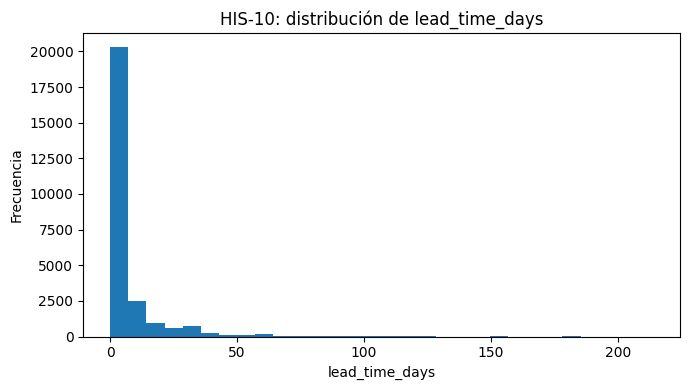

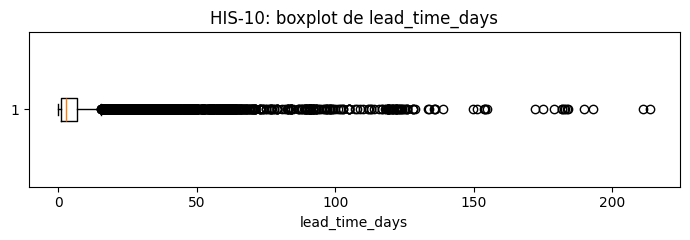

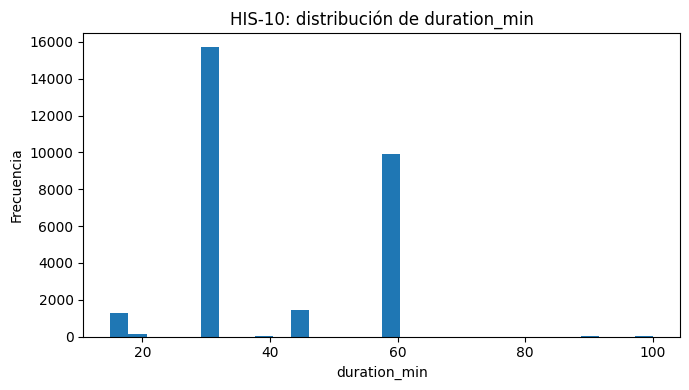

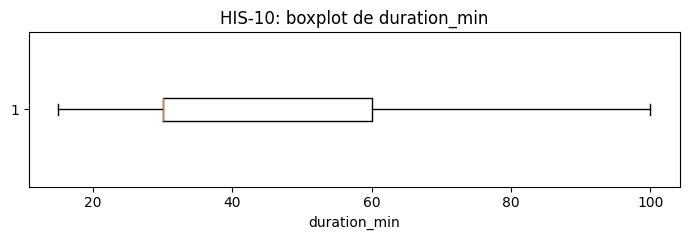

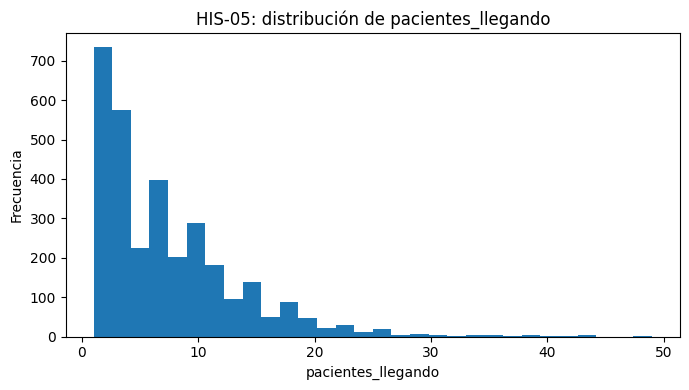

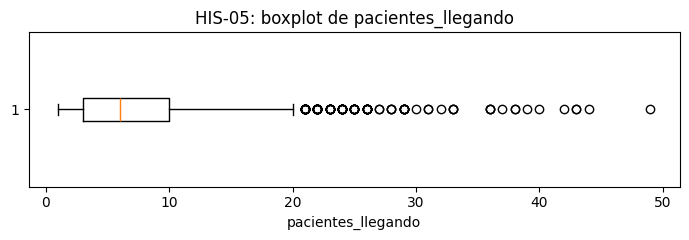

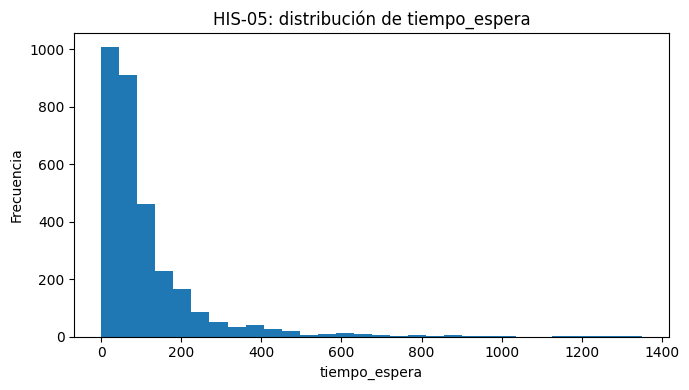

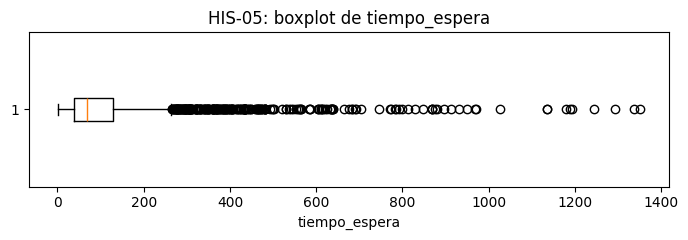

In [349]:
# ============================================================
# Visualización de distribuciones de variables numéricas clave
# ============================================================
# Se seleccionan variables numéricas relevantes de HIS-10 y HIS-05.
#
# Para HIS-10 se revisan:
# - lead_time_days: anticipación de la cita.
# - duration_min: duración programada de la cita.
#
# Para HIS-05 se revisan:
# - pacientes_llegando: volumen horario de llegadas a urgencias.
# - tiempo_espera: proxy promedio de espera por hora.
#
# Para cada variable se genera:
# - histograma: permite observar concentración, sesgo y dispersión.
# - boxplot: permite identificar mediana, rango intercuartílico y posibles outliers.

plot_cols = [
    ("HIS-10", preprocessed_data_his10, "lead_time_days"),
    ("HIS-10", preprocessed_data_his10, "duration_min"),
    ("HIS-05", master_table_his05, "pacientes_llegando"),
    ("HIS-05", master_table_his05, "tiempo_espera"),
]


# ============================================================
# Generación de histogramas y boxplots
# ============================================================
# Se recorre cada variable seleccionada, se convierte a formato numérico
# y se eliminan valores faltantes únicamente para efectos de visualización.
# Los valores no se eliminan del dataset original.

for dataset_name, df, col in plot_cols:
    if col not in df.columns:
        continue

    s = pd.to_numeric(df[col], errors="coerce").dropna()

    if s.empty:
        continue

    # Histograma: muestra la forma de la distribución.
    plt.figure(figsize=(7, 4))
    plt.hist(s, bins=30)
    plt.title(f"{dataset_name}: distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    # Boxplot: muestra mediana, dispersión y posibles valores extremos.
    plt.figure(figsize=(7, 2.5))
    plt.boxplot(s, vert=False)
    plt.title(f"{dataset_name}: boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Las gráficas muestran histogramas y boxplots de variables numéricas clave seleccionadas manualmente por su relevancia para los casos HIS-10 e HIS-05. No se grafican todas las variables numéricas, sino aquellas que ayudan a revisar anticipación de citas, duración, volumen de llegadas y proxy de espera.

En **HIS-10**, `lead_time_days` presenta una distribución fuertemente sesgada a la derecha. La mayoría de las citas se agenda con pocos días de anticipación, pero existen casos con anticipaciones mucho mayores, incluso superiores a 100 o 200 días. El boxplot confirma una gran cantidad de valores extremos. Estos valores no necesariamente son errores, pero sí deben tratarse con cuidado en modelado, ya que pueden influir de forma desproporcionada.

La variable `duration_min` muestra una distribución más discreta y concentrada en duraciones estándar, principalmente alrededor de 30 y 60 minutos. El boxplot no muestra outliers importantes, lo cual sugiere que la duración de las citas tiene rangos razonables y más controlados.

En **HIS-05**, `pacientes_llegando` también presenta sesgo positivo. La mayoría de las horas tienen pocos o moderados registros de llegada, pero existen horas con mayor volumen, llegando hasta valores cercanos a 50. Estos picos pueden representar momentos de mayor saturación o demanda en urgencias.

La variable `tiempo_espera` muestra una distribución fuertemente sesgada a la derecha. La mayoría de las horas tiene tiempos de espera relativamente bajos o moderados, pero existen valores extremos muy altos. El boxplot confirma la presencia de múltiples outliers. Como esta variable es un proxy operativo y no el tiempo oficial clínico de espera, estos valores deben interpretarse con cautela y podrían requerir transformaciones, filtros o métodos robustos en la etapa de modelado.

En conjunto, las gráficas confirman que varias variables relevantes no siguen distribuciones normales y presentan sesgo positivo. Por ello, no conviene asumir normalidad ni eliminar valores extremos automáticamente. En cambio, deben documentarse y considerarse en decisiones posteriores de modelado.

## 9.1 Revisión de valores imposibles

Además de identificar outliers, se revisan reglas básicas para detectar valores imposibles o sospechosos en variables numéricas y temporales relevantes.

Estas reglas no necesariamente eliminan datos de forma automática, pero ayudan a identificar registros que deben tratarse con cuidado antes del modelado. En particular, se revisan condiciones como duraciones no plausibles, horas fuera de rango, tiempos negativos, edades fuera de rango, valores de espera demasiado altos y valores inválidos en el target.

Esta revisión es importante porque algunos valores extremos pueden ser casos reales, mientras que otros pueden deberse a errores de captura, fechas mal registradas o inconsistencias entre tablas.

Reglas consideradas:

- `duration_min <= 0`: duración de cita imposible.
- `appointment_hour < 0` o `appointment_hour > 23`: hora de cita fuera del rango válido.
- `lead_time_days < 0`: cita registrada después de la fecha programada.
- `m_edad_num < 0` o `m_edad_num > 120`: edad no plausible.
- `pacientes_llegando <= 0`: horas sin llegadas dentro de una tabla construida a partir de actividad en urgencias.
- `tiempo_espera < 0`: espera negativa.
- `tiempo_espera > 1440`: espera mayor a 24 horas.
- `no_show` fuera de `{0, 1}`: valor inválido para un target binario.

In [350]:
# ============================================================
# Revisión de valores imposibles o sospechosos
# ============================================================
# Se construye una lista de validaciones para variables numéricas clave.
# Cada validación aplica una regla de negocio simple para detectar valores
# que no deberían ocurrir o que requieren revisión antes del modelado.

impossible_checks = []


# ============================================================
# Función auxiliar para aplicar reglas de validación
# ============================================================
# Esta función recibe:
# - nombre de la tabla,
# - dataframe,
# - columna a revisar,
# - condición lógica que define el valor imposible,
# - descripción de la regla.
#
# Después calcula cuántos registros incumplen la regla y qué porcentaje
# representan dentro de la tabla.

def add_impossible_check(table_name, df, column, condition, description):
    # Si la columna no existe en el dataframe, se omite la validación.
    if column not in df.columns:
        return

    # Se convierte la columna a numérica para poder aplicar comparaciones.
    # Los valores no convertibles se transforman en NaN.
    s = pd.to_numeric(df[column], errors="coerce")
    
    # Se aplica la condición definida para identificar valores imposibles.
    mask = condition(s).fillna(False)

    impossible_checks.append({
        "table": table_name,
        "column": column,
        "rule": description,
        "count": int(mask.sum()),
        "pct": round(mask.mean() * 100, 2),
    })


# ============================================================
# Reglas para HIS-10
# ============================================================
# Se revisan variables numéricas relacionadas con citas médicas.
# Las reglas buscan detectar duraciones imposibles, horas fuera de rango,
# tiempos de anticipación negativos y edades no plausibles.

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "duration_min",
    lambda s: s <= 0,
    "duration_min <= 0",
)

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "appointment_hour",
    lambda s: (s < 0) | (s > 23),
    "appointment_hour outside 0-23",
)

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "lead_time_days",
    lambda s: s < 0,
    "lead_time_days < 0",
)

add_impossible_check(
    "preprocessed_data_his10",
    preprocessed_data_his10,
    "m_edad_num",
    lambda s: (s < 0) | (s > 120),
    "m_edad_num outside 0-120",
)


# ============================================================
# Reglas para HIS-05
# ============================================================
# Se revisan variables numéricas relacionadas con urgencias.
# pacientes_llegando debe ser positivo porque la tabla se construye
# a partir de horas con actividad registrada.
#
# tiempo_espera debe estar entre 0 y 1440 minutos, ya que valores negativos
# o mayores a 24 horas no son plausibles como proxy de espera inicial.

add_impossible_check(
    "master_table_his05",
    master_table_his05,
    "pacientes_llegando",
    lambda s: s <= 0,
    "pacientes_llegando <= 0",
)

add_impossible_check(
    "master_table_his05",
    master_table_his05,
    "tiempo_espera",
    lambda s: (s < 0) | (s > 24 * 60),
    "tiempo_espera outside 0-1440 minutes",
)


# ============================================================
# Validación del dominio del target HIS-10
# ============================================================
# El target no_show debe ser binario:
# - 0: asistencia
# - 1: inasistencia / no-show
#
# Cualquier valor fuera de {0, 1} sería inválido para clasificación binaria.

if "no_show" in preprocessed_data_his10.columns:
    invalid_target = ~preprocessed_data_his10["no_show"].isin([0, 1])
    
    impossible_checks.append({
        "table": "preprocessed_data_his10",
        "column": "no_show",
        "rule": "no_show outside {0, 1}",
        "count": int(invalid_target.sum()),
        "pct": round(invalid_target.mean() * 100, 2),
    })


# ============================================================
# Resumen de valores imposibles
# ============================================================
# Se muestra una tabla con el resultado de todas las reglas aplicadas.

pd.DataFrame(impossible_checks)

,table,column,rule,count,pct
0,preprocessed_data_his10,duration_min,duration_min <= 0,0,0.0
1,preprocessed_data_his10,appointment_hour,appointment_hour outside 0-23,0,0.0
2,preprocessed_data_his10,lead_time_days,lead_time_days < 0,0,0.0
3,preprocessed_data_his10,m_edad_num,m_edad_num outside 0-120,1,0.0
4,master_table_his05,pacientes_llegando,pacientes_llegando <= 0,0,0.0
5,master_table_his05,tiempo_espera,tiempo_espera outside 0-1440 minutes,0,0.0
6,preprocessed_data_his10,no_show,"no_show outside {0, 1}",0,0.0


La revisión de valores imposibles muestra resultados favorables en la mayoría de las reglas aplicadas.

En **HIS-10**, no se detectan duraciones de cita menores o iguales a cero, horas de cita fuera del rango válido `0–23`, ni valores negativos en `lead_time_days`. Esto indica que las variables principales de duración, horario y anticipación de cita tienen rangos lógicamente válidos. Además, el target `no_show` solo contiene valores dentro del dominio esperado `{0, 1}`, por lo que es válido para un problema de clasificación binaria.

La única regla con observaciones detectadas corresponde a `m_edad_num`, donde aparece 1 registro fuera del rango plausible de 0 a 120 años. Aunque el porcentaje es prácticamente 0%, este hallazgo refuerza que `m_edad_num` no debe usarse directamente sin revisión adicional, especialmente porque previamente se observó que esta variable tiene una proporción muy alta de faltantes.

En **HIS-05**, no se detectan horas con `pacientes_llegando <= 0`, lo cual es consistente con una tabla construida a partir de horas con actividad en urgencias. Tampoco se detectan valores de `tiempo_espera` fuera del rango definido de 0 a 1440 minutos, lo que indica que los tiempos agregados en la tabla final ya respetan la regla de validez del proxy de espera.

En conjunto, estas reglas no muestran problemas graves de valores imposibles en las variables principales. Los principales puntos de atención siguen siendo la baja calidad de `m_edad_num`, los valores extremos previamente observados y las fechas fuera de rango detectadas en la validación temporal.

## 10. Variables categóricas

Se revisan las variables categóricas principales de los datasets finales para detectar valores raros, categorías dominantes, alta cardinalidad y posibles inconsistencias de codificación.

Este análisis es importante porque las variables categóricas pueden aportar información relevante al modelo, pero también pueden generar problemas si tienen demasiadas categorías, valores poco frecuentes, categorías mal escritas o una concentración excesiva en un solo valor.

En esta sección no se corrigen automáticamente todas las categorías; primero se documenta su distribución para decidir si conviene agrupar categorías raras, conservarlas, codificarlas como `UNKNOWN` o excluir variables con baja utilidad.

In [351]:
# ============================================================
# Función auxiliar para perfilar variables categóricas
# ============================================================
# Esta función muestra, para cada variable categórica seleccionada:
# - número de valores únicos,
# - categorías más frecuentes,
# - conteo de registros por categoría,
# - porcentaje que representa cada categoría dentro del dataset.
#
# Esto ayuda a detectar alta cardinalidad, categorías dominantes,
# valores raros o presencia excesiva de UNKNOWN.

def categorical_profile(df, cols, top_n=15):
    for col in cols:
        # Si la columna no existe en el dataframe, se omite.
        if col not in df.columns:
            continue

        # Se calculan las categorías más frecuentes.
        counts = (
            df[col]
            .value_counts(dropna=False)
            .head(top_n)
            .to_frame("count")
        )

        # Se agrega el porcentaje respecto al total de registros.
        counts["pct"] = (counts["count"] / len(df) * 100).round(2)

        print("=" * 80)
        print(col)
        print("unique values:", df[col].nunique(dropna=True))
        display(counts)


# ============================================================
# Variables categóricas relevantes para HIS-10
# ============================================================
# Se revisan variables provenientes de:
# - agenda médica: area, med, esp, tpo_cita;
# - campos operativos de la cita: conflicto, agregada, ultimahora, buffer;
# - episodio/atención: p_status, p_sexo;
# - paciente: m_sexo, m_cp, m_edo.
#
# Estas variables pueden aportar información para predecir no-show,
# pero también pueden presentar alta cardinalidad, categorías dominantes
# o muchos valores UNKNOWN.

his10_categorical = [
    "area",
    "med",
    "esp",
    "tpo_cita",
    "conflicto",
    "agregada",
    "ultimahora",
    "buffer",
    "p_status",
    "p_sexo",
    "m_sexo",
    "m_cp",
    "m_edo",
]


# ============================================================
# Features de conteo de triage para HIS-05
# ============================================================
# En la tabla final de HIS-05, la variable categórica original de triage
# ya fue transformada en columnas de conteo por hora.
#
# Ejemplo:
# - triage_A
# - triage_C
# - triage_E
# - triage_M
# - triage_N
#
# Por eso, en HIS-05 no se perfilan como categorías individuales,
# sino como conteos agregados de eventos por clasificación de triage.
#
# Se excluye triage_events porque representa el total de eventos de triage,
# no una categoría específica.

his05_triage_count_features = [
    col for col in master_table_his05.columns
    if col.startswith("triage_") and col != "triage_events"
]


# ============================================================
# Perfil categórico de HIS-10
# ============================================================
# Se muestran las categorías más frecuentes de las variables seleccionadas.
# Esto permite identificar:
# - variables con pocos valores dominantes,
# - variables con muchos valores únicos,
# - variables con alta proporción de UNKNOWN,
# - posibles variables que requieran agrupación o tratamiento especial.

print("HIS-10 categorical variables")
categorical_profile(preprocessed_data_his10, his10_categorical)


# ============================================================
# Totales de eventos de triage en HIS-05
# ============================================================
# Se suman los conteos de cada categoría de triage en todas las horas
# de master_table_his05.
#
# Esto permite conocer qué clasificaciones de triage aparecen con mayor
# frecuencia en la base horaria final.

print("HIS-05 triage count features")
display(
    master_table_his05[his05_triage_count_features]
    .sum()
    .sort_values(ascending=False)
    .to_frame("total_events")
)

HIS-10 categorical variables
area
unique values: 6


,count,pct
area,,
CZM,18146,63.56
PLY,8567,30.01
TUL,669,2.34
MAH,555,1.94
PTM,477,1.67
CUN,137,0.48


med
unique values: 127


,count,pct
med,,
703,1780,6.23
336,1360,4.76
000068,1281,4.49
605,1169,4.09
679,1068,3.74
001081,862,3.02
000985,821,2.88
1013,812,2.84
249,773,2.71


esp
unique values: 45


...

,count,pct
m_cp,,
UNKNOWN,26585,93.11
77600,990,3.47
77645,153,0.54
77580,136,0.48
77667,124,0.43
77710,108,0.38
00000,47,0.16
77660,41,0.14
000,39,0.14


m_edo
unique values: 38


,count,pct
m_edo,,
UNKNOWN,21572,75.56
23,3745,13.12
29,1068,3.74
NA,813,2.85
31,621,2.18
06,131,0.46
21,116,0.41
24,65,0.23
16,61,0.21


HIS-05 triage count features


,total_events
triage_N,5294.0
triage_M,2686.0
triage_A,848.0
triage_E,123.0
triage_C,29.0


La revisión de variables categóricas muestra diferencias importantes entre las variables seleccionadas de HIS-10 y las features de triage de HIS-05.

En **HIS-10**, la variable `area` tiene 6 categorías, pero está concentrada principalmente en `CZM` y `PLY`, que juntas representan más del 93% de los registros. Esto indica que el dataset está dominado por esas dos áreas, por lo que el modelo podría aprender patrones principalmente de ellas y tener menos información para áreas con poca representación como `CUN`, `PTM`, `MAH` o `TUL`.

La variable `med` presenta 127 valores únicos, lo que indica alta cardinalidad. Esto puede aportar información relevante, ya que distintos médicos pueden tener diferentes patrones de agenda o asistencia, pero también requiere cuidado en el modelado para evitar sobreajuste o categorías con pocos registros.

La variable `esp` tiene 45 especialidades y una distribución más repartida. Las especialidades con mayor presencia son `MEDGEN`, `FISIOT`, `RADIOL`, `GINECO` y `ORTOPE`. Esta variable puede ser útil para el modelo, ya que la inasistencia podría variar dependiendo del tipo de servicio o especialidad.

La variable `tpo_cita` tiene dos categorías principales: `P` con 66.33% y `S` con 33.67%. Esta distribución es manejable y la variable parece aprovechable para modelado.

Las variables `conflicto`, `agregada` y `ultimahora` tienen una proporción extremadamente alta de `UNKNOWN`, superior al 99% en varios casos. Esto indica baja completitud o poca variabilidad, por lo que probablemente aporten poca información al modelo inicial. Podrían conservarse inicialmente, pero deben evaluarse con cuidado.

La variable `buffer` está dominada por `N`, con 99.29% de los registros. Aunque tiene pocos valores distintos, su baja variabilidad puede limitar su utilidad predictiva.

En `p_status`, se observan principalmente los códigos `00`, `50` y `02`. Esta variable podría aportar información, pero debe revisarse su significado operativo, ya que si representa un estado posterior a la cita podría generar fuga de información (*data leakage*).

Las variables de sexo (`p_sexo` y `m_sexo`) muestran principalmente valores `F` y `M`. En `m_sexo` aparece además un 10.13% de `UNKNOWN`, lo cual refleja que no todas las citas pudieron enriquecerse completamente con datos demográficos desde `HOSMPI`.

Las variables de ubicación, como `m_cp` y `m_edo`, tienen una proporción muy alta de `UNKNOWN`: 93.11% en código postal y 75.56% en estado. Esto limita su utilidad directa como variables predictoras. Además, aparecen valores como `00000`, `000` o `NA`, que podrían requerir homologación adicional como valores faltantes o no informativos.

Para **HIS-05**, las categorías de triage ya fueron transformadas en columnas de conteo por hora. La categoría con mayor número de eventos es `triage_N`, seguida por `triage_M`, `triage_A`, `triage_E` y `triage_C`. Esto muestra que algunas clasificaciones de triage son mucho más frecuentes que otras, por lo que las categorías menos comunes podrían tener menor peso estadístico en el modelo.

En conjunto, esta revisión muestra que algunas variables categóricas son útiles y manejables, como `area`, `esp`, `tpo_cita`, `p_sexo` y `m_sexo`, mientras que otras presentan alta cardinalidad, baja variabilidad o demasiados valores `UNKNOWN`. Estas variables no necesariamente deben eliminarse en Data Engineering, pero sí deben revisarse en la etapa de modelado para decidir su codificación, agrupación o exclusión.

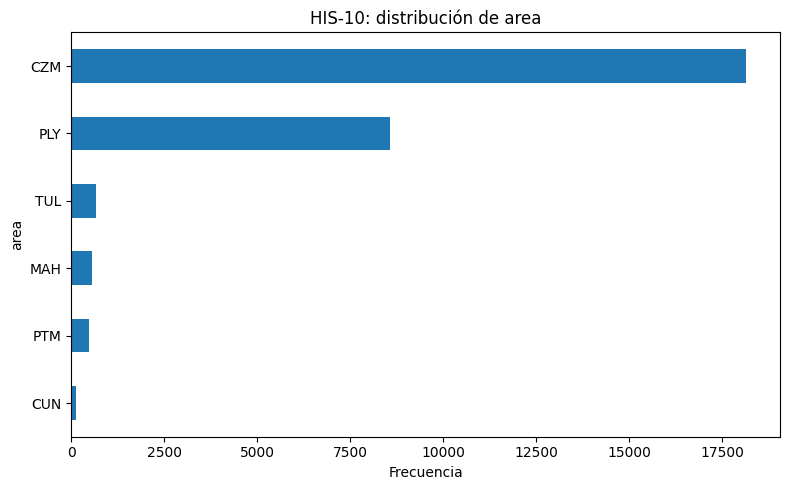

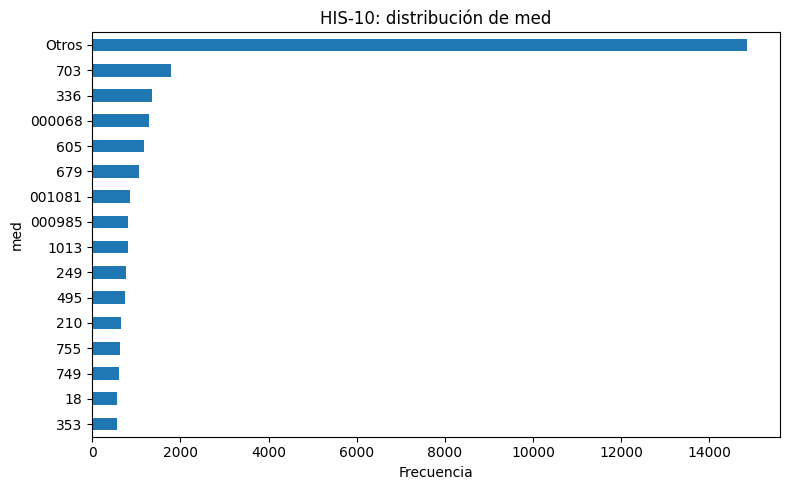

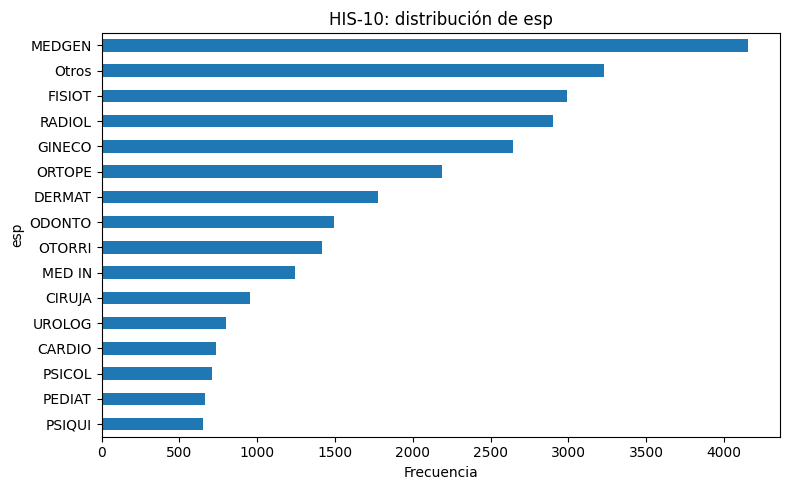

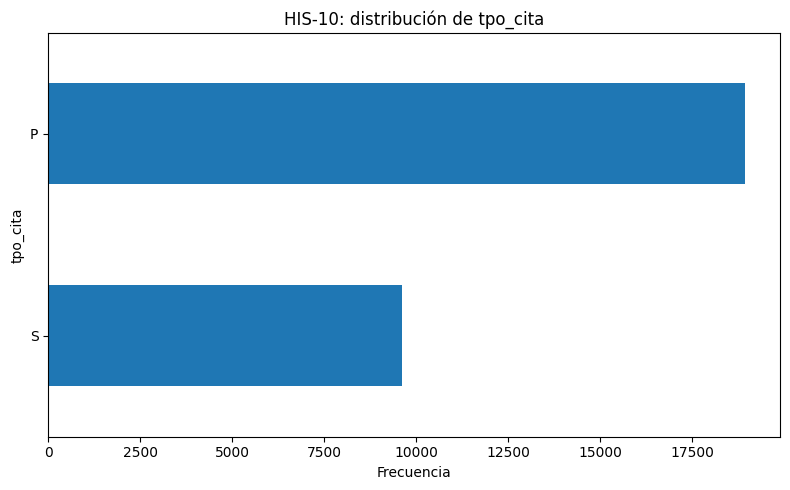

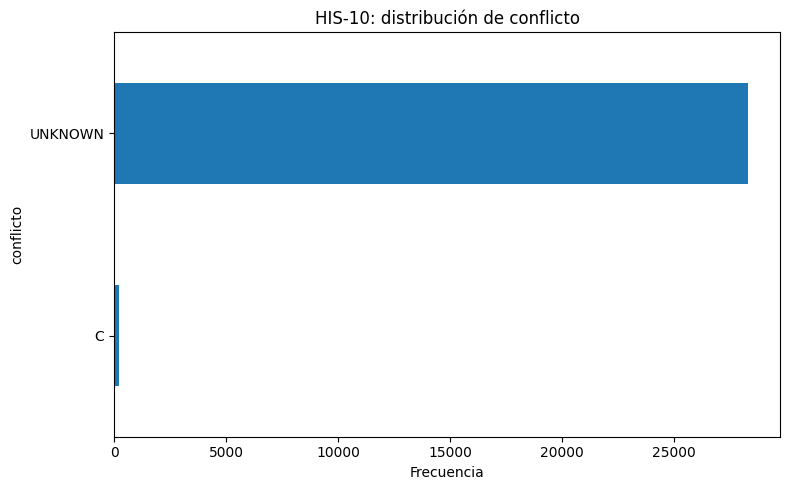

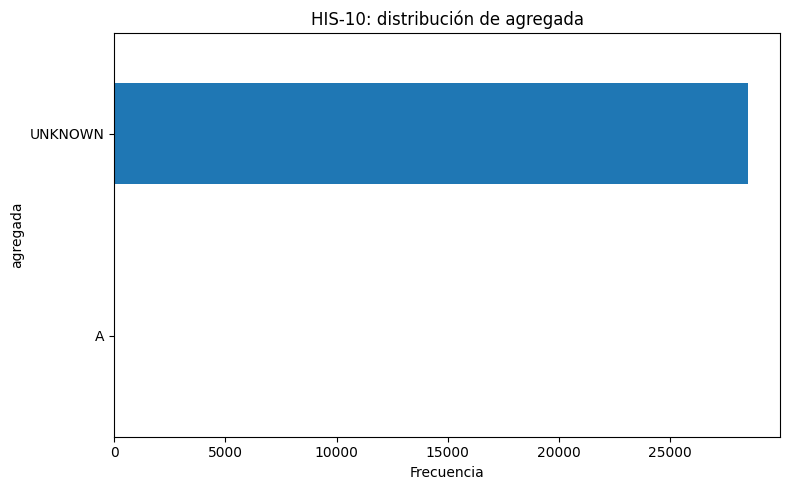

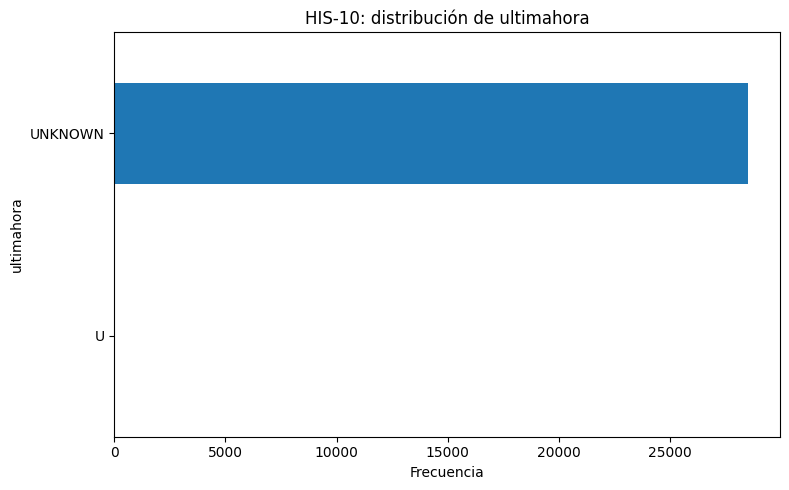

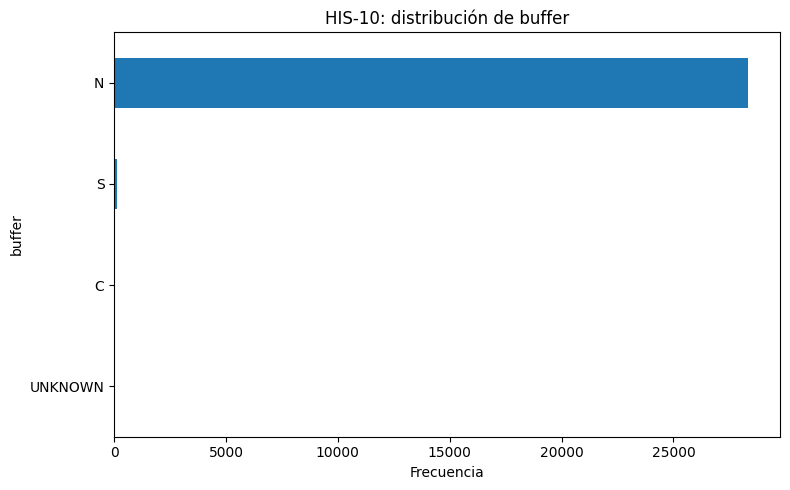

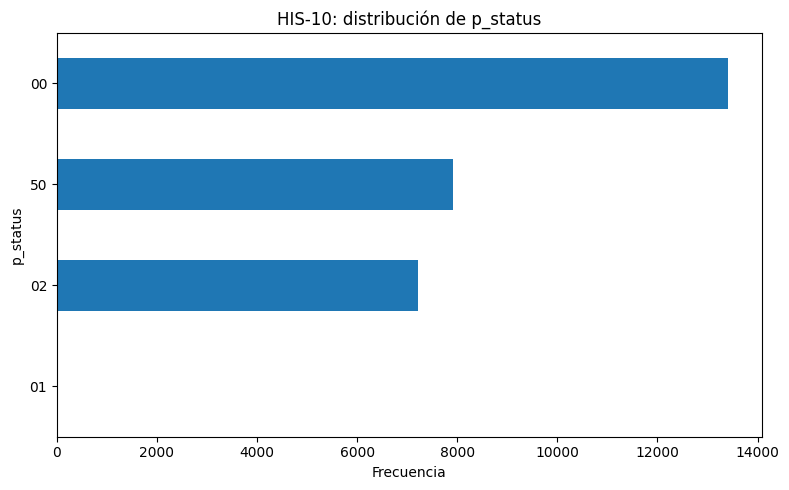

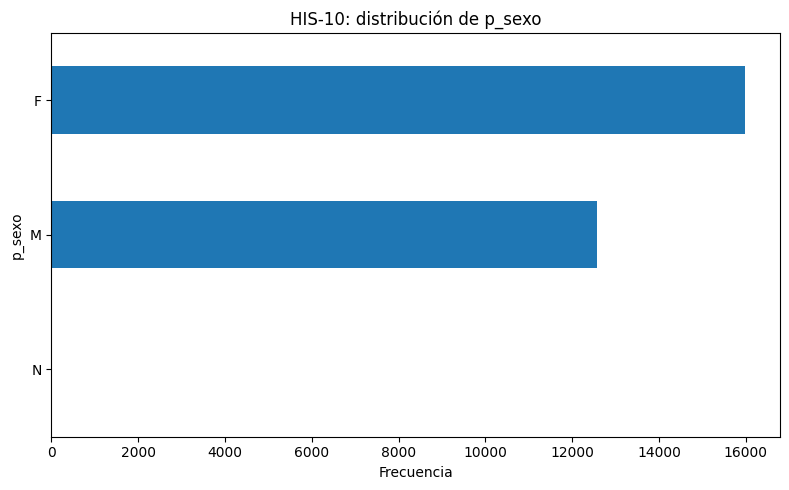

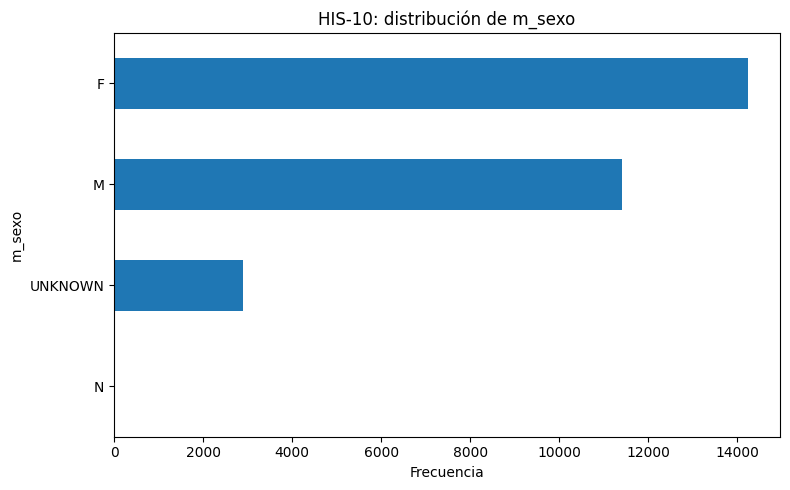

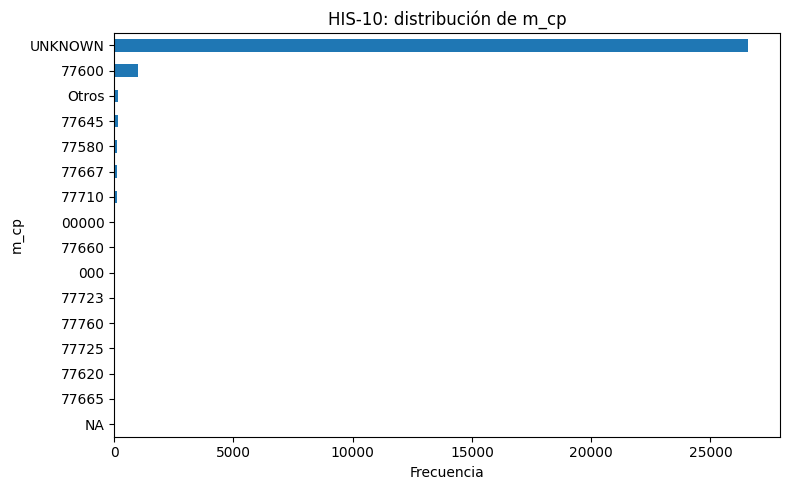

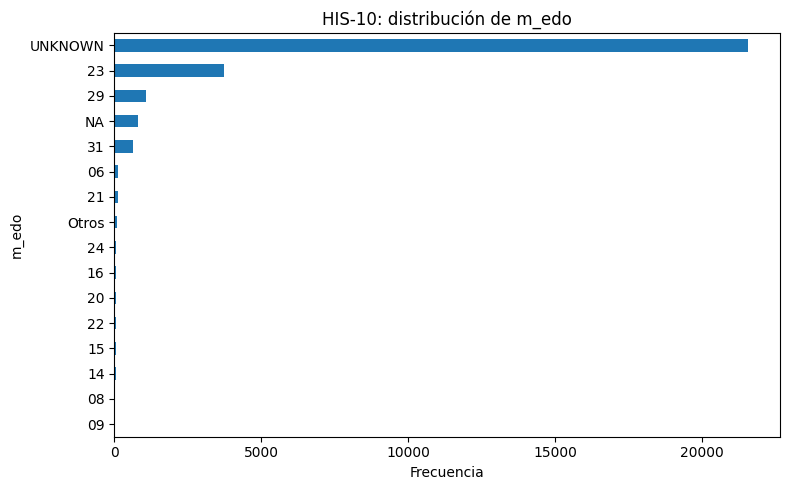

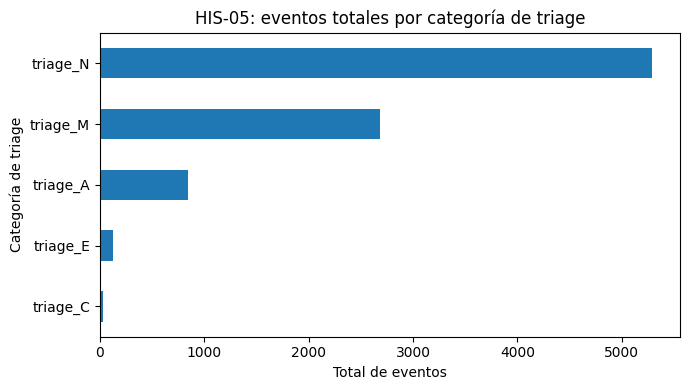

In [352]:
# ============================================================
# Función auxiliar para graficar variables categóricas
# ============================================================
# Esta función genera una gráfica de barras horizontales para una variable categórica.
#
# La gráfica muestra las categorías más frecuentes y, si existen más categorías
# que el límite definido por top_n, agrupa las restantes en una categoría llamada "Otros".
#
# Esto permite visualizar variables con muchas categorías sin saturar la gráfica.

def plot_categorical_counts(df, col, top_n=15, title_prefix=""):
    # Si la columna no existe en el dataframe, se omite la gráfica.
    if col not in df.columns:
        return

    # Se calculan las frecuencias de cada categoría.
    # dropna=False permite incluir valores faltantes si existieran.
    counts = df[col].value_counts(dropna=False)

    # Se conservan únicamente las categorías más frecuentes.
    counts_top = counts.head(top_n).copy()

    # Si hay más categorías fuera del top_n, se agrupan como "Otros".
    # Esto es útil para variables de alta cardinalidad como médico o código postal.
    if len(counts) > top_n:
        counts_top.loc["Otros"] = counts.iloc[top_n:].sum()

    # Se ordenan las barras de menor a mayor para mejorar la lectura visual.
    counts_top = counts_top.sort_values()

    # Se genera la gráfica de barras horizontales.
    plt.figure(figsize=(8, 5))
    counts_top.plot(kind="barh")
    plt.title(f"{title_prefix}: distribución de {col}")
    plt.xlabel("Frecuencia")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


# ============================================================
# Selección de variables categóricas HIS-10
# ============================================================
# Se seleccionan variables representativas del dataset final de HIS-10.
#
# Incluyen variables de:
# - agenda médica: area, med, esp, tpo_cita;
# - operación de la cita: conflicto, agregada, ultimahora, buffer;
# - episodio/atención: p_status, p_sexo;
# - paciente: m_sexo, m_cp, m_edo.
#
# La selección se enfoca en variables relevantes para revisar concentración,
# alta cardinalidad, valores UNKNOWN y posibles problemas de codificación.

his10_categorical_to_plot = [
    "area",
    "med",
    "esp",
    "tpo_cita",
    "conflicto",
    "agregada",
    "ultimahora",
    "buffer",
    "p_status",
    "p_sexo",
    "m_sexo",
    "m_cp",
    "m_edo",
]


# ============================================================
# Gráficas de variables categóricas HIS-10
# ============================================================
# Se genera una gráfica de barras para cada variable seleccionada.
#
# Para variables con muchas categorías, solo se muestran las 15 más frecuentes
# y el resto se agrupa en "Otros".

for col in his10_categorical_to_plot:
    plot_categorical_counts(
        df=preprocessed_data_his10,
        col=col,
        top_n=15,
        title_prefix="HIS-10"
    )


# ============================================================
# Selección de features de triage en HIS-05
# ============================================================
# En el dataset final de HIS-05, las categorías de triage ya no aparecen
# como una sola variable categórica.
#
# Durante la construcción de la tabla horaria, cada categoría de triage se
# convirtió en una columna de conteo por hora, por ejemplo:
# - triage_A
# - triage_C
# - triage_E
# - triage_M
# - triage_N
#
# Se excluye triage_events porque representa el total de eventos de triage,
# no una categoría específica.

his05_triage_count_features = [
    col for col in master_table_his05.columns
    if col.startswith("triage_") and col != "triage_events"
]


# ============================================================
# Cálculo de eventos totales por categoría de triage
# ============================================================
# Se suman los conteos horarios de cada categoría para conocer
# el volumen total de eventos por clasificación de triage.

triage_totals = (
    master_table_his05[his05_triage_count_features]
    .sum()
    .sort_values(ascending=True)
)


# ============================================================
# Gráfica de eventos de triage en HIS-05
# ============================================================
# Se grafica el total acumulado de eventos por categoría de triage.
# Esto permite identificar cuáles clasificaciones son más frecuentes
# en la base horaria final.

plt.figure(figsize=(7, 4))
triage_totals.plot(kind="barh")
plt.title("HIS-05: eventos totales por categoría de triage")
plt.xlabel("Total de eventos")
plt.ylabel("Categoría de triage")
plt.tight_layout()
plt.show()

Las gráficas categóricas complementan el perfil tabular anterior y permiten visualizar con mayor claridad la concentración de categorías.

En HIS-10, las gráficas confirman que `area` está dominada por `CZM` y `PLY`, mientras que variables como `med` y `esp` tienen mayor diversidad de categorías. También se observa que `conflicto`, `agregada` y `ultimahora` están dominadas por `UNKNOWN`, y que `buffer` está casi completamente concentrada en `N`.

Las variables demográficas y de ubicación muestran comportamientos distintos: `p_sexo` y `m_sexo` tienen una distribución relativamente interpretable entre `F` y `M`, aunque `m_sexo` conserva una proporción de `UNKNOWN`. En cambio, variables como `m_cp` y `m_edo` están muy dominadas por `UNKNOWN`, lo que limita su utilidad directa para modelado.

Para HIS-05, la gráfica de triage confirma que `triage_N` y `triage_M` concentran la mayor parte de los eventos, mientras que categorías como `triage_E` y `triage_C` aparecen con mucha menor frecuencia.

En conjunto, las visualizaciones refuerzan los hallazgos del perfil tabular: algunas variables categóricas son potencialmente útiles y manejables, mientras que otras presentan alta cardinalidad, baja variabilidad o demasiados valores `UNKNOWN`.

## 10.1 Revisión de typos e inconsistencias categóricas

Se revisan variables categóricas para identificar posibles inconsistencias de escritura, espacios residuales, diferencias de mayúsculas/minúsculas, categorías raras, códigos sospechosos o valores que podrían representar faltantes de forma no estandarizada.

Esta revisión complementa el análisis de cardinalidad y frecuencias, ya que una variable puede tener una distribución aparentemente válida, pero aun así contener categorías mal codificadas o inconsistentes.

El objetivo no es corregir manualmente todas las categorías en el notebook, sino detectar posibles problemas que deban documentarse o tratarse posteriormente en el pipeline de limpieza o en la etapa de modelado.

In [353]:
# ============================================================
# Revisión automática de inconsistencias textuales categóricas
# ============================================================
# En esta celda se revisan posibles inconsistencias de escritura en variables
# categóricas, como:
# - espacios al inicio o final,
# - diferencias de mayúsculas/minúsculas,
# - acentos o marcas diacríticas,
# - valores codificados como UNKNOWN, NA, N/A o cadenas vacías.
#
# Esta revisión no valida si una categoría es correcta según su significado,
# sino si hay señales de escritura inconsistente o faltantes no informativos.

import unicodedata


# ============================================================
# Función auxiliar para normalizar texto
# ============================================================
# Esta función convierte cualquier valor categórico a una versión comparable:
# - Si el valor es faltante, lo marca como "MISSING".
# - Convierte el valor a string.
# - Elimina espacios al inicio y al final.
# - Convierte a mayúsculas.
# - Elimina acentos.
#
# Ejemplo:
# "  médgen " -> "MEDGEN"

def normalize_text_value(value):
    if pd.isna(value):
        return "MISSING"

    value = str(value).strip().upper()
    value = "".join(
        char for char in unicodedata.normalize("NFKD", value)
        if not unicodedata.combining(char)
    )
    return value


# ============================================================
# Función auxiliar para revisar columnas categóricas
# ============================================================
# Para cada columna seleccionada, se calcula:
# - raw_unique: número de categorías originales.
# - normalized_unique: número de categorías después de normalizar texto.
# - possible_text_inconsistency: indica si la normalización redujo categorías.
# - missing_or_unknown_count: conteo de valores faltantes o no informativos.
#
# Si normalized_unique < raw_unique, puede existir inconsistencia textual,
# por ejemplo la misma categoría escrita con espacios, acentos o mayúsculas distintas.

def categorical_typo_check(table_name, df, cols):
    rows = []

    for col in cols:
        # Si la columna no existe en la tabla, se omite.
        if col not in df.columns:
            continue

        # Se toma la versión original como texto.
        raw = df[col].astype("string")

        # Se crea una versión normalizada.
        normalized = raw.map(normalize_text_value)

        # Se cuentan valores faltantes o codificados como no informativos.
        missing_or_unknown_count = int(
            raw.isna().sum()
            + raw.str.strip().str.upper().isin(
                ["UNKNOWN", "MISSING", "NA", "N/A", ""]
            ).sum()
        )

        rows.append({
            "table": table_name,
            "column": col,
            "raw_unique": int(raw.nunique(dropna=True)),
            "normalized_unique": int(normalized.nunique(dropna=True)),
            "possible_text_inconsistency": int(
                normalized.nunique(dropna=True) < raw.nunique(dropna=True)
            ),
            "missing_or_unknown_count": missing_or_unknown_count,
        })

    return pd.DataFrame(rows)


# ============================================================
# Aplicación de la revisión a variables categóricas seleccionadas
# ============================================================
# Se revisan:
#
# 1. preprocessed_data_his10:
#    Variables categóricas finales de HIS-10.
#
# 2. processed_hosagd:
#    asistencia_clean, porque de esta variable se construye no_show.
#
# 3. processed_triage:
#    variables categóricas relevantes de urgencias.
#
# El objetivo es identificar columnas con posibles inconsistencias textuales
# o alta presencia de UNKNOWN / NA / faltantes.

categorical_typo_summary = pd.concat(
    [
        categorical_typo_check(
            "preprocessed_data_his10",
            preprocessed_data_his10,
            [
                "area",
                "med",
                "esp",
                "tpo_cita",
                "conflicto",
                "agregada",
                "ultimahora",
                "buffer",
                "p_status",
                "p_sexo",
                "m_sexo",
                "m_cp",
                "m_edo",
            ],
        ),
        categorical_typo_check(
            "processed_hosagd",
            processed_hosagd,
            ["asistencia_clean"],
        ),
        categorical_typo_check(
            "processed_triage",
            processed_triage,
            ["triage_clean", "Sexo", "Area", "Destino"],
        ),
    ],
    ignore_index=True,
)


# ============================================================
# Ordenamiento del resumen
# ============================================================
# Se ordenan primero las variables con posible inconsistencia textual,
# después las que tienen más valores faltantes/UNKNOWN,
# y finalmente las de mayor cardinalidad.
#
# Esto ayuda a priorizar qué variables revisar con más detalle.

categorical_typo_summary = categorical_typo_summary.sort_values(
    ["possible_text_inconsistency", "missing_or_unknown_count", "raw_unique"],
    ascending=False,
)

categorical_typo_summary

,table,column,raw_unique,normalized_unique,possible_text_inconsistency,missing_or_unknown_count
1,preprocessed_data_his10,med,127,126,1,0
2,preprocessed_data_his10,esp,45,31,1,0
13,processed_hosagd,asistencia_clean,4,5,0,44463
5,preprocessed_data_his10,agregada,2,2,0,28520
6,preprocessed_data_his10,ultimahora,2,2,0,28520
4,preprocessed_data_his10,conflicto,2,2,0,28324
11,preprocessed_data_his10,m_cp,75,75,0,26598
12,preprocessed_data_his10,m_edo,38,38,0,22385
16,processed_triage,Area,0,1,0,9942
10,preprocessed_data_his10,m_sexo,4,4,0,2891


El resumen automático de inconsistencias categóricas muestra que la mayoría de las variables no presenta cambios entre el número de categorías crudas y normalizadas. Esto indica que, en general, no hay problemas fuertes por espacios, acentos o diferencias de mayúsculas/minúsculas en la mayoría de las columnas revisadas.

Las principales posibles inconsistencias textuales aparecen en `med` y `esp`. En `med`, el número de categorías pasa de 127 a 126 después de normalizar, lo que sugiere que al menos dos códigos podrían diferir únicamente por formato textual. En `esp`, el cambio es mayor: pasa de 45 categorías crudas a 31 categorías normalizadas. Esto indica que algunas especialidades podrían estar repetidas con variaciones de escritura, espacios, acentos o diferencias de formato. Por ello, `esp` es una variable candidata para revisión u homologación adicional.

También se observa que algunas variables tienen una gran cantidad de valores faltantes o codificados como `UNKNOWN`. En `asistencia_clean`, hay 44,463 valores faltantes, lo cual coincide con lo observado previamente: solo las citas con `A` o `I` se usan para construir el target de HIS-10. Las variables `agregada`, `ultimahora` y `conflicto` también tienen una cantidad muy alta de valores `UNKNOWN`, lo que confirma su baja completitud y posible baja utilidad directa para el modelo inicial.

Las variables demográficas y de ubicación, como `m_cp` y `m_edo`, también presentan muchos valores no informativos. En particular, `m_cp` tiene 26,598 valores faltantes o no informativos, y `m_edo` tiene 22,385. Esto refuerza que las variables de ubicación deben tratarse con cuidado antes de usarse como predictoras.

En `processed_triage`, la columna `Area` aparece completamente vacía o no informativa, con 9,942 valores faltantes o desconocidos. Por otro lado, `triage_clean`, `Sexo`, `area`, `tpo_cita`, `p_status` y `p_sexo` no muestran señales relevantes de inconsistencia textual ni valores faltantes importantes.

En conjunto, esta revisión confirma que el principal problema categórico no son errores masivos de escritura, sino variables con alta proporción de `UNKNOWN` o faltantes. Además, `esp` y, en menor medida, `med`, sí requieren atención porque la normalización reduce el número de categorías, lo cual sugiere posibles duplicados semánticos por formato.

In [354]:
# ============================================================
# Validación de dominios esperados en variables categóricas clave
# ============================================================
# La revisión anterior detecta inconsistencias textuales, pero no necesariamente
# detecta valores inválidos según el significado de cada variable.
#
# Por ejemplo:
# - asistencia_clean debe ser A o I para construir el target.
# - no_show debe ser 0 o 1.
# - triage_clean debe estar dentro de las clasificaciones esperadas.
#
# Esta celda revisa dominios esperados para variables críticas.

expected_domains = {
    "asistencia_clean": {"A", "I"},
    "no_show": {0, 1},
    "tpo_cita": {"P", "S"},
    "p_sexo": {"F", "M", "N", "UNKNOWN"},
    "m_sexo": {"F", "M", "N", "UNKNOWN"},
    "triage_clean": {"A", "C", "E", "M", "N"},
}


# ============================================================
# Fuentes donde se revisarán dominios
# ============================================================
# Se revisan las tablas donde aparecen variables categóricas críticas:
#
# - processed_hosagd:
#   contiene asistencia_clean antes de construir la base final.
#
# - preprocessed_data_his10:
#   contiene variables categóricas finales y el target no_show.
#
# - processed_triage:
#   contiene la clasificación de triage ya limpia.

domain_sources = [
    ("processed_hosagd", processed_hosagd),
    ("preprocessed_data_his10", preprocessed_data_his10),
    ("processed_triage", processed_triage),
]


# ============================================================
# Aplicación de reglas de dominio
# ============================================================
# Para cada variable con dominio esperado:
# - se ignoran valores faltantes,
# - se identifican valores explícitos fuera del dominio permitido,
# - se cuenta cuántos valores inválidos hay,
# - se guardan algunos ejemplos de valores inválidos.
#
# Esto permite detectar códigos raros aunque estén escritos de forma consistente.

domain_checks = []

for table_name, df in domain_sources:
    for col, valid_values in expected_domains.items():
        # Si la columna no existe en esa tabla, se omite.
        if col not in df.columns:
            continue

        values = df[col]

        # Se ignoran faltantes y se detectan valores explícitos inválidos.
        invalid_mask = values.notna() & ~values.isin(valid_values)

        domain_checks.append({
            "table": table_name,
            "column": col,
            "expected_domain": sorted(valid_values),
            "invalid_count": int(invalid_mask.sum()),
            "invalid_pct": round(invalid_mask.mean() * 100, 2),
            "invalid_examples": values[invalid_mask]
                .drop_duplicates()
                .head(10)
                .tolist(),
        })


# ============================================================
# Resumen de validación de dominios
# ============================================================
# Se muestra una tabla con:
# - tabla,
# - columna,
# - dominio esperado,
# - cantidad de valores inválidos,
# - porcentaje de valores inválidos,
# - ejemplos de valores inválidos.

domain_checks_df = pd.DataFrame(domain_checks)
domain_checks_df

,table,column,expected_domain,invalid_count,invalid_pct,invalid_examples
0,processed_hosagd,asistencia_clean,"[A, I]",4,0.01,"[, ]"
1,processed_hosagd,no_show,"[0, 1]",0,0.00,[]
2,processed_hosagd,tpo_cita,"[P, S]",0,0.00,[]
3,preprocessed_data_his10,no_show,"[0, 1]",0,0.00,[]
4,preprocessed_data_his10,tpo_cita,"[P, S]",0,0.00,[]
5,preprocessed_data_his10,p_sexo,"[F, M, N, UNKNOWN]",0,0.00,[]
6,preprocessed_data_his10,m_sexo,"[F, M, N, UNKNOWN]",0,0.00,[]
7,processed_triage,triage_clean,"[A, C, E, M, N]",0,0.00,[]


La validación de dominios esperados muestra que las variables categóricas críticas están, en general, dentro de los valores permitidos.

En `processed_hosagd`, la variable `asistencia_clean` presenta 4 valores inválidos, equivalentes al 0.01% de los registros. Estos valores corresponden a caracteres no interpretables y no pertenecen al dominio esperado `{A, I}`. Por lo tanto, no deben usarse para construir el target de HIS-10. Esto coincide con la lógica del pipeline, donde solo `A` e `I` se traducen a `no_show`.

La variable `no_show` no presenta valores fuera del dominio `{0, 1}` ni en `processed_hosagd` ni en `preprocessed_data_his10`. Esto confirma que el target final quedó correctamente codificado como variable binaria para clasificación.

La variable `tpo_cita` tampoco presenta valores fuera del dominio esperado `{P, S}`, tanto en `processed_hosagd` como en `preprocessed_data_his10`. Esto indica que el tipo de cita quedó estandarizado y sin códigos inesperados en las bases revisadas.

Las variables de sexo (`p_sexo` y `m_sexo`) no presentan valores fuera del dominio definido `{F, M, N, UNKNOWN}`. Esto significa que los valores observados están dentro de los códigos permitidos, aunque `UNKNOWN` debe interpretarse como información faltante o no disponible.

Finalmente, `triage_clean` no presenta valores fuera del dominio `{A, C, E, M, N}`, por lo que la clasificación de triage quedó dentro de los códigos esperados.

En conjunto, esta validación muestra que no hay problemas relevantes de dominio en las variables categóricas críticas. El principal hallazgo son los 4 valores inválidos en `asistencia_clean`, pero estos ya quedan fuera del dataset final de HIS-10 porque no se convierten en un target válido.

In [355]:
# ============================================================
# Revisión manual de dominios categóricos seleccionados
# ============================================================
# Además del resumen automático y la validación de dominios,
# se revisan manualmente algunas variables críticas.
#
# Esta revisión ayuda a inspeccionar valores raros específicos, por ejemplo:
# - caracteres no interpretables en asistencia_clean,
# - códigos poco frecuentes en sexo,
# - categorías de triage,
# - códigos postales no informativos como UNKNOWN, 00000, 000 o NA.

selected_categorical_domains = {
    "processed_hosagd.asistencia_clean": processed_hosagd["asistencia_clean"],
    "preprocessed_data_his10.p_sexo": preprocessed_data_his10["p_sexo"],
    "preprocessed_data_his10.m_sexo": preprocessed_data_his10["m_sexo"],
    "processed_triage.triage_clean": processed_triage["triage_clean"],
    "preprocessed_data_his10.m_cp": preprocessed_data_his10["m_cp"],
}


# ============================================================
# Conteo de valores frecuentes por variable seleccionada
# ============================================================
# Se muestran los 20 valores más frecuentes de cada variable,
# incluyendo faltantes, para facilitar la inspección manual.
#
# Esta celda complementa la validación automática porque permite ver
# directamente cuáles son los códigos o categorías que aparecen en los datos.

for name, series in selected_categorical_domains.items():
    print("=" * 80)
    print(name)

    display(
        series
        .value_counts(dropna=False)
        .head(20)
        .to_frame("count")
    )

processed_hosagd.asistencia_clean


,count
asistencia_clean,
<NA>,44463
A,21325
I,7226
,3
,1


preprocessed_data_his10.p_sexo


,count
p_sexo,
F,15989
M,12561
N,1


preprocessed_data_his10.m_sexo


,count
m_sexo,
F,14251
M,11403
UNKNOWN,2891
N,6


processed_triage.triage_clean


,count
triage_clean,
N,5740
M,3001
A,1005
E,147
C,49


preprocessed_data_his10.m_cp


,count
m_cp,
UNKNOWN,26585
77600,990
77645,153
77580,136
77667,124
77710,108
00000,47
77660,41
000,39


La revisión de typos e inconsistencias categóricas se realizó sobre variables críticas de los datasets finales y de algunas tablas procesadas intermedias. Aunque idealmente esta revisión podría hacerse antes de la construcción final de los datasets, aquí se mantiene como una validación complementaria para documentar problemas que podrían afectar el modelado.

El resumen automático muestra que la mayoría de las variables categóricas no presenta diferencias importantes entre las categorías crudas y normalizadas, por lo que no hay evidencia de problemas generalizados por espacios, acentos o diferencias de mayúsculas/minúsculas. Sin embargo, `med` y `esp` sí muestran reducción en el número de categorías después de normalizar. En `med`, las categorías pasan de 127 a 126, mientras que en `esp` pasan de 45 a 31. Esto sugiere que algunas especialidades o códigos médicos podrían estar repetidos con variaciones de formato, por lo que serían candidatas a homologación adicional.

También se confirma que varias columnas tienen alta presencia de valores faltantes o no informativos. En particular, `asistencia_clean` tiene 44,463 valores faltantes; `agregada`, `ultimahora` y `conflicto` están dominadas por `UNKNOWN`; y variables de ubicación como `m_cp` y `m_edo` tienen muchos valores desconocidos o poco informativos. Esto refuerza que no todas las variables categóricas tienen la misma utilidad para modelado.

La validación de dominios esperados muestra resultados favorables en las variables críticas. El target `no_show` no presenta valores fuera de `{0, 1}`, tanto en la tabla procesada como en el dataset final de HIS-10. `tpo_cita`, `p_sexo`, `m_sexo` y `triage_clean` también se mantienen dentro de sus dominios esperados. El único problema puntual aparece en `asistencia_clean`, donde existen 4 valores inválidos con caracteres no interpretables. Estos registros no se usan para construir el target final, ya que solo `A` e `I` se consideran etiquetas válidas.

La revisión manual confirma estos hallazgos. En `processed_hosagd.asistencia_clean`, los valores válidos son `A` e `I`, además de muchos faltantes y 4 caracteres raros. En `preprocessed_data_his10.p_sexo`, la variable está prácticamente concentrada en `F` y `M`, con un solo caso `N`. En `m_sexo`, también predominan `F` y `M`, aunque aparece una proporción relevante de `UNKNOWN`, lo que indica que no todas las citas pudieron enriquecerse con información demográfica desde `HOSMPI`.

En `processed_triage.triage_clean`, las categorías están dentro del dominio esperado y se concentran principalmente en `N` y `M`, seguidas por `A`, `E` y `C`. Esta variable se revisa en la tabla procesada porque en el dataset final de HIS-05 ya fue transformada en conteos horarios por categoría de triage. Por otro lado, `m_cp` presenta una gran cantidad de `UNKNOWN` y valores como `00000`, `000` o `NA`, que podrían representar códigos postales no informativos o faltantes codificados de otra forma.

En conjunto, la revisión muestra que no hay problemas graves de dominio en las variables categóricas principales. Los hallazgos más importantes son: posibles inconsistencias de formato en `med` y `esp`, alta presencia de `UNKNOWN` en variables operativas y de ubicación, 4 valores inválidos en `asistencia_clean` y códigos no informativos en `m_cp`. Estas observaciones no bloquean la construcción de los datasets finales, pero deben considerarse al decidir qué variables conservar, homologar, agrupar o excluir en la etapa de modelado.

## 11. Desbalance de clases para HIS-10

Para **HIS-10**, la variable objetivo es `no_show`, donde `0` representa asistencia y `1` representa inasistencia o No-Show.

Las citas con asistencia desconocida no se usan para el entrenamiento inicial, ya que imputar el resultado real de una cita podría sesgar el modelo.

En esta sección se revisa la distribución de clases para identificar si el target está balanceado. Esto es importante porque un desbalance fuerte puede hacer que el modelo favorezca la clase mayoritaria y que métricas como accuracy sean poco representativas.

In [356]:
# ============================================================
# Conteo de clases del target HIS-10
# ============================================================
# Se cuenta cuántas citas pertenecen a cada clase del target no_show.
#
# Codificación:
# - 0: el paciente asistió.
# - 1: el paciente no asistió / no-show.

target_counts = (
    preprocessed_data_his10["no_show"]
    .value_counts()
    .sort_index()
)


# ============================================================
# Porcentaje de clases del target HIS-10
# ============================================================
# Además del conteo absoluto, se calcula el porcentaje que representa
# cada clase dentro del dataset final de HIS-10.
#
# Esto permite evaluar si existe desbalance entre citas asistidas
# y citas no asistidas.

target_pct = (
    preprocessed_data_his10["no_show"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)


# ============================================================
# Construcción de tabla resumen del target
# ============================================================
# Se integran conteos y porcentajes en una sola tabla para facilitar
# la interpretación del balance de clases.

target_summary = pd.DataFrame({
    "count": target_counts,
    "pct": target_pct.round(2),
})


# ============================================================
# Etiquetado de clases
# ============================================================
# Se renombran los índices para que la tabla sea más clara:
# - 0 = asistió.
# - 1 = no-show.

target_summary.index = ["0 = asistió", "1 = no-show"]


# ============================================================
# Visualización del resumen
# ============================================================
# Se muestra la distribución final del target de HIS-10.

target_summary

,count,pct
0 = asistió,21325,74.69
1 = no-show,7226,25.31


La distribución del target `no_show` muestra que el dataset final de HIS-10 tiene **21,325 citas asistidas** y **7,226 citas no asistidas**.

Esto equivale a:

- **74.69%** de citas con asistencia (`no_show = 0`).
- **25.31%** de citas con inasistencia o No-Show (`no_show = 1`).

Por lo tanto, existe un desbalance moderado entre las clases: la clase mayoritaria corresponde a citas asistidas. Sin embargo, la clase de No-Show todavía representa una proporción considerable del dataset, por lo que no es un caso extremo de desbalance.

Este resultado es importante para la etapa de modelado porque un modelo podría favorecer la clase mayoritaria si se evalúa únicamente con accuracy. Por ello, para HIS-10 conviene considerar métricas como precision, recall, F1-score y matriz de confusión, especialmente para evaluar qué tan bien se identifican los casos de No-Show.

In [357]:
# ============================================================
# Complemento HIS-05: horas sin proxy válido de espera
# ============================================================
# HIS-05 no tiene desbalance de clases, pero sí conviene revisar
# cuántas horas finales no tienen registros válidos para calcular espera.

hours_without_valid_wait = (
    master_table_his05["wait_proxy_valid_count"] == 0
).sum()

hours_without_valid_wait_pct = (
    hours_without_valid_wait / len(master_table_his05) * 100
)

print("Horas totales HIS-05:", len(master_table_his05))
print("Horas sin proxy de espera válido:", hours_without_valid_wait)
print("Porcentaje de horas sin proxy válido:", round(hours_without_valid_wait_pct, 2), "%")

Horas totales HIS-05: 3132
Horas sin proxy de espera válido: 35
Porcentaje de horas sin proxy válido: 1.12 %


Para HIS-05 no se realiza análisis de desbalance de clases, porque no existe un target binario como en HIS-10. La revisión equivalente ya se cubrió en el perfil de variables numéricas y en las visualizaciones de llegadas y tiempos de espera.

Como complemento, se revisó cuántas horas de la tabla final no tienen proxy válido de espera. De las 3,132 horas totales, solo 35 horas no tienen proxy válido, lo que equivale al 1.12% de la base.

Esto indica que la gran mayoría de las horas cuenta con información suficiente para calcular métricas de espera. Sin embargo, esas 35 horas deben tratarse con cuidado si posteriormente se modela `tiempo_espera`, ya que tienen llegadas registradas pero no una métrica confiable de espera.

## 12. Validación de outputs generados por Kedro

Después de ejecutar el pipeline formal de Data Engineering con:

`kedro run --pipeline data_engineering`

se espera que Kedro genere archivos locales en las capas configuradas del proyecto, principalmente en:

- `data/02_intermediate/`: tablas limpias o procesadas intermedias.
- `data/03_primary/`: datasets finales listos para ser utilizados por etapas posteriores, como Data Science.

Esta validación permite confirmar que las funciones usadas en el notebook no solo funcionan de forma exploratoria, sino que también están integradas correctamente al flujo reproducible del proyecto.

Los archivos generados no se suben a GitHub porque la carpeta `data/` está ignorada en el repositorio. Por ello, en lugar de versionar los datos, se versiona el código del pipeline, la configuración del catálogo y la lógica de transformación. Cada integrante puede regenerar los outputs ejecutando el pipeline correspondiente.

In [358]:
# ============================================================
# Definición de outputs esperados del pipeline
# ============================================================
# Se define un diccionario con los datasets que deberían generarse después
# de ejecutar:
#
# kedro run --pipeline data_engineering
#
# Los outputs intermedios se esperan en data/02_intermediate/
# y los datasets finales en data/03_primary/.

expected_outputs = {
    "processed_hospac": DATA_INTERMEDIATE / "processed_hospac.parquet",
    "processed_hosagd": DATA_INTERMEDIATE / "processed_hosagd.parquet",
    "processed_hosmpi": DATA_INTERMEDIATE / "processed_hosmpi.parquet",
    "processed_triage": DATA_INTERMEDIATE / "processed_triage.parquet",
    "processed_notamedicaurg": DATA_INTERMEDIATE / "processed_notamedicaurg.parquet",
    "preprocessed_data_his10": DATA_PRIMARY / "preprocessed_data_his10.parquet",
    "master_table_his05": DATA_PRIMARY / "master_table_his05.parquet",
}


# ============================================================
# Revisión de existencia y dimensiones de outputs
# ============================================================
# Para cada archivo esperado se revisa:
# - si existe localmente,
# - en qué ruta relativa se encuentra,
# - qué dimensiones tiene si existe.
#
# Esto permite confirmar que Kedro generó correctamente los datasets
# definidos en el pipeline de Data Engineering.

output_check = []

for name, path in expected_outputs.items():
    # Verifica si el archivo existe en la ruta esperada.
    exists = path.exists()

    # Si el archivo existe, se lee para obtener su número de filas y columnas.
    # Si no existe, shape se mantiene como None.
    shape = None
    if exists:
        shape = pd.read_parquet(path).shape

    output_check.append({
        "dataset": name,
        "path": str(path.relative_to(PROJECT_ROOT)),
        "exists": exists,
        "shape": shape,
    })


# ============================================================
# Tabla resumen de validación de outputs
# ============================================================
# Se muestra una tabla con el estado de cada output esperado.
# La columna exists indica si el archivo fue generado correctamente,
# y shape permite comparar sus dimensiones contra las obtenidas en el notebook.

pd.DataFrame(output_check)

,dataset,path,exists,shape
0,processed_hospac,data\02_intermediate\processed_hospac.parquet,True,"(115593, 12)"
1,processed_hosagd,data\02_intermediate\processed_hosagd.parquet,True,"(73018, 25)"
2,processed_hosmpi,data\02_intermediate\processed_hosmpi.parquet,True,"(37460, 10)"
3,processed_triage,data\02_intermediate\processed_triage.parquet,True,"(9942, 13)"
4,processed_notamedicaurg,data\02_intermediate\processed_notamedicaurg.p...,True,"(22847, 14)"
5,preprocessed_data_his10,data\03_primary\preprocessed_data_his10.parquet,True,"(28551, 27)"
6,master_table_his05,data\03_primary\master_table_his05.parquet,True,"(3132, 16)"


La validación de outputs confirma que todos los archivos esperados del pipeline de Data Engineering fueron generados correctamente por Kedro.

Los cinco datasets procesados aparecen en `data/02_intermediate/`:

- `processed_hospac`
- `processed_hosagd`
- `processed_hosmpi`
- `processed_triage`
- `processed_notamedicaurg`

Además, los dos datasets finales aparecen en `data/03_primary/`:

- `preprocessed_data_his10`
- `master_table_his05`

La columna `exists = True` en todos los casos indica que los archivos existen en las rutas esperadas. Además, las dimensiones coinciden con las obtenidas previamente dentro del notebook. Por ejemplo, `preprocessed_data_his10` tiene **28,551 filas y 27 columnas**, mientras que `master_table_his05` tiene **3,132 filas y 16 columnas**.

Esto confirma que las transformaciones no quedaron solo como análisis exploratorio dentro del notebook, sino que también están integradas al pipeline reproducible de Kedro. En otras palabras, cualquier integrante del equipo puede regenerar estas tablas ejecutando el pipeline, sin depender de pasos manuales del notebook.

## 13. Conclusiones

Conclusiones principales:

1. Las cinco tablas principales (`HOSPAC`, `HOSAGD`, `HOSMPI`, `NOTAMEDICAURG` y `TRIAGE`) permiten construir las bases analíticas para los dos casos de uso seleccionados: **HIS-10** y **HIS-05**.

2. Para **HIS-10**, `HOSAGD` es la tabla base porque contiene la agenda de citas médicas y el campo `asistencia`, a partir del cual se construye el target `no_show`.

3. El target `no_show` se construye únicamente con valores de asistencia conocidos: `A` se codifica como `no_show = 0` y `I` se codifica como `no_show = 1`. Los valores vacíos, desconocidos o no interpretables no se imputan, porque inventar el resultado real de una cita podría sesgar el modelo.

4. El dataset final de HIS-10 queda con **28,551 registros y 27 columnas**, a nivel **cita médica con target válido**. La validación de granularidad confirma que no hay llaves de cita duplicadas en la base etiquetada.

5. Para integrar `HOSAGD` con `HOSPAC`, la llave correcta es `area_key + cve_num_key + cve_mbo_key`. No se debe unir únicamente por `cve_num_key + cve_mbo_key`, porque esas claves pueden repetirse entre áreas. Esta unión conserva las 73,018 citas de `HOSAGD` y logra una correspondencia prácticamente completa con `HOSPAC`.

6. La integración posterior con `HOSMPI` permite enriquecer HIS-10 con datos demográficos del paciente. Sin embargo, la tasa de correspondencia con `HOSMPI` es de 82.7%, por lo que algunas citas no cuentan con información demográfica completa.

7. El target de HIS-10 presenta un desbalance moderado: **74.69%** de citas asistidas y **25.31%** de no-show. Por ello, en modelado no conviene evaluar únicamente con accuracy; también deben considerarse métricas como precision, recall, F1-score y matriz de confusión.

8. Para **HIS-05**, `NOTAMEDICAURG` y `TRIAGE` se integran a nivel temporal. La base final no está a nivel paciente o cita, sino a nivel **hora de operación en urgencias**.

9. Debido a que `AtMed_Hora` no contiene información suficiente, se construye un proxy operativo de espera como `note_datetime - arrival_datetime`. Este proxy no debe interpretarse como tiempo oficial clínico de atención, sino como una aproximación útil para el MVP.

10. Los valores negativos o mayores a 24 horas en el proxy de espera no se eliminan directamente; se marcan mediante `valid_wait_proxy` para evitar que se usen en métricas agregadas de espera.

11. El dataset final de HIS-05 queda con **3,132 registros y 16 columnas**, a nivel **una fila por hora**. La validación de granularidad confirma que no hay `timestamp` duplicados.

12. La integración temporal de HIS-05 conserva todas las horas base provenientes de `NOTAMEDICAURG`. Además, 2,743 de las 3,132 horas tienen eventos de `TRIAGE` asociados, lo que representa una cobertura temporal de 87.58%.

13. En HIS-05 no existe desbalance de clases como en HIS-10, ya que no se trata de un problema binario. La revisión equivalente se realiza sobre variables de saturación y espera, como `pacientes_llegando`, `tiempo_espera`, `tiempo_espera_mediana` y `wait_proxy_valid_count`.

14. Solo 35 de las 3,132 horas de HIS-05 no tienen proxy válido de espera, equivalente al 1.12%. Estas horas deben tratarse con cuidado si posteriormente se modela `tiempo_espera`.

15. La revisión de duplicados muestra que no hay duplicados problemáticos en las llaves principales de HIS-10. En `NOTAMEDICAURG`, la alta repetición de `clave_ingreso_key` no se interpreta automáticamente como error, sino como evidencia de que la tabla tiene granularidad de nota médica o evento clínico, no necesariamente de ingreso único.

16. La revisión de variables numéricas muestra que varias variables presentan sesgo positivo y valores extremos, especialmente `lead_time_days`, `pacientes_llegando`, `tiempo_espera` y `tiempo_espera_mediana`. Estos valores no deben eliminarse automáticamente, pero sí deben considerarse en la etapa de modelado.

17. La variable `m_edad_num` no quedó usable en su estado actual, ya que presenta una proporción muy alta de faltantes y algunos valores no plausibles. Una alternativa más adecuada sería calcular la edad a partir de `m_fec_nac_clean` y la fecha de la cita.

18. La revisión de variables categóricas muestra que algunas variables son potencialmente útiles para modelado, como `area`, `esp`, `tpo_cita`, `p_sexo` y `m_sexo`. Sin embargo, otras presentan alta cardinalidad, baja variabilidad o muchos valores `UNKNOWN`, como `med`, `conflicto`, `agregada`, `ultimahora`, `m_cp` y `m_edo`.

19. La revisión de typos e inconsistencias categóricas no muestra problemas graves de dominio en las variables críticas. El principal hallazgo son 4 valores inválidos en `asistencia_clean`, los cuales no afectan el dataset final porque no se convierten en target válido.

20. La validación de outputs confirma que Kedro genera correctamente los datasets intermedios en `data/02_intermediate/` y los datasets finales en `data/03_primary/`. Esto demuestra que el proceso no depende de pasos manuales del notebook, sino que está integrado al pipeline reproducible de Data Engineering.

21. Quedan como consideraciones para la etapa de Data Science: tratamiento de outliers, evaluación de variables con muchos `UNKNOWN`, posible fuga de información en variables como `p_status`, estrategia de imputación numérica, codificación de variables categóricas de alta cardinalidad, tratamiento del desbalance de HIS-10 y filtrado o manejo de fechas fuera de rango operativo.

## 14. Resumen de acciones de Data Wrangling

| Problema detectado | Acción realizada | Etapa / Caso |
|---|---|---|
| Fechas y horas almacenadas como texto | Se convirtieron a columnas `datetime` para fechas de cita, llegada, registro, nota médica y triage | Data Engineering |
| Horas con formatos heterogéneos | Se estandarizaron a formato horario consistente antes de construir columnas temporales | Data Engineering |
| Strings vacíos o con espacios | Se limpiaron espacios y se estandarizaron cadenas vacías como valores faltantes | Data Engineering |
| Columnas crudas con demasiadas variables no necesarias | Se seleccionaron columnas relevantes para cada caso de uso y se generaron variables auxiliares | Data Engineering |
| Faltantes ocultos como cadenas vacías | Se aplicó una revisión extendida de faltantes considerando espacios y cadenas vacías | Calidad de datos |
| Fechas fuera de rango o sospechosas | Se identificaron en la validación temporal para documentarlas antes del modelado | Calidad de datos |
| `asistencia` vacía, desconocida o no interpretable | No se imputó; solo `A` e `I` se usaron como etiquetas válidas | HIS-10 |
| Caracteres inválidos en `asistencia_clean` | Se documentaron como valores fuera del dominio esperado y no se usaron para construir el target final | HIS-10 |
| Construcción del target `no_show` | `A` se codificó como `0` y `I` como `1` | HIS-10 |
| Desbalance moderado en `no_show` | Se documentó la distribución de clases para considerar métricas como precision, recall y F1-score | HIS-10 / Data Science |
| Cruce incorrecto potencial entre `HOSAGD` y `HOSPAC` | Se usó la llave compuesta `area_key + cve_num_key + cve_mbo_key` para evitar duplicados artificiales | Integración HIS-10 |
| Posibles duplicados por llaves de negocio | Se revisaron duplicados por llaves relevantes, no solo duplicados completos | Calidad de datos |
| Cobertura incompleta al cruzar con `HOSMPI` | Se documentó la tasa de match con datos demográficos del paciente | Integración HIS-10 |
| Categóricas faltantes en HIS-10 | Se conservaron como `UNKNOWN` cuando aplica | HIS-10 |
| Numéricas faltantes | No se imputaron en Data Engineering; se dejan para estrategia de modelado | Data Science |
| `m_edad_num` con demasiados faltantes | Se documentó que no debe usarse directamente y que conviene calcular edad desde `m_fec_nac_clean` | HIS-10 / Data Science |
| Variables de ubicación con muchos `UNKNOWN` | Se documentó su baja completitud y posible baja utilidad directa | HIS-10 / Data Science |
| Alta cardinalidad en variables categóricas como `med` | Se documentó para decidir codificación, agrupación o exclusión en modelado | Data Science |
| Posibles inconsistencias textuales en `med` y `esp` | Se detectaron mediante normalización de texto y se documentaron como candidatas a homologación | Calidad de datos |
| Variables categóricas con baja variabilidad (`conflicto`, `agregada`, `ultimahora`, `buffer`) | Se documentó su concentración en `UNKNOWN` o en una sola categoría | HIS-10 / Data Science |
| Posible fuga de información en `p_status` | Se marcó como variable que debe revisarse antes de modelado | Data Science |
| `AtMed_Hora` sin información suficiente | Se construyó un proxy de espera usando `note_datetime - arrival_datetime` | HIS-05 |
| Proxy de espera negativo o mayor a 24 horas | Se marcó con `valid_wait_proxy` para excluirlo de métricas agregadas de espera | HIS-05 |
| Horas sin proxy válido de espera | Se cuantificaron para saber qué parte de la tabla final no tiene métrica confiable de espera | HIS-05 |
| Integración HIS-05 no relacional sino temporal | Se agregaron `NOTAMEDICAURG` y `TRIAGE` por hora y se unieron mediante `timestamp` | Integración HIS-05 |
| Cobertura parcial de triage por hora | Se calculó la tasa de horas con eventos de triage asociados | HIS-05 |
| Repetición de `clave_ingreso_key` en `NOTAMEDICAURG` | Se interpretó como evidencia de granularidad de nota médica/evento clínico, no necesariamente como error | HIS-05 |
| Outliers en `lead_time_days`, llegadas y espera | Se identificaron con estadísticos, regla IQR, histogramas y boxplots | Calidad de datos / Data Science |
| Valores imposibles en variables numéricas | Se aplicaron reglas de validación para duración, hora, anticipación, edad, llegadas, espera y target | Calidad de datos |
| Diferente granularidad de los datasets finales | Se validó que HIS-10 quedara a nivel cita y HIS-05 a nivel hora | Validación final |
| Outputs locales de Kedro | Se verificó existencia y dimensiones de archivos en `data/02_intermediate/` y `data/03_primary/` | Kedro / Reproducibilidad |
| Archivos de datos ignorados por GitHub | Se documentó que los outputs se regeneran ejecutando el pipeline, no versionando `data/` | Reproducibilidad |